In [1]:
# data tools and plotting

from feature_eng import TSFE
import logging
import warnings
from pandas.errors import PerformanceWarning
warnings.filterwarnings("ignore", category=FutureWarning)

warnings.filterwarnings("ignore", category=PerformanceWarning)
logging.getLogger("mlgflow.sklearn").setLevel(logging.ERROR)

#====================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# Model from scikit-learn

# Model Evaluations

from sklearn.metrics import RocCurveDisplay


from sklearn.model_selection import  TimeSeriesSplit

from sklearn.metrics import PrecisionRecallDisplay

pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 1000);

feature_cols= [#'datetime', 
  #'tamb',  'pamb' ,
  #'psamp',
  'type',
  'pflow', 'tmod',  'CH4_rt', 'CH4_w',
       'CH4_ht', 'CH4_area', 'CH4_skew', 'CH4_start_time', 'CH4_end_time',
       'CH4_start_level', 'CH4_end_level', #'duration', 
       'is_air','is_std',
       #'previous_type_std', 'previous_type_air','next_type_std', 'next_type_air', 
       ]

feature_config ={
    'diff':{'cols': ['CH4_area', 
                    'CH4_ht','CH4_w' , 'CH4_rt' #'tmod',#'CH4_end_time','CH4_start_time',,'CH4_rt'
                ], 'periods':[1, 3, 6, 72]},

    'lag':{'cols':['CH4_area', 'CH4_rt',  'CH4_ht', #'tmod',  'psamp','pamb','tamb',,'CH4_skew'
                'pflow',
              'CH4_w'], 'periods':[1, 3, 6, 72]},

    'diff_cross':{'cols':[['CH4_ht', 'CH4_ht_lag_72'],
                          ['CH4_area', 'CH4_area_lag_72'],
                          ['CH4_end_time', 'CH4_start_time'],
                      # ['CH4_w_roll_mean_2h', 'CH4_w_roll_mean_7h'],
                        ['CH4_end_level', 'CH4_start_level'],
                        ['CH4_rt', 'pflow'],
                        #['CH4_ht', 'CH4_ht_lag_72'],['CH4_w', 'CH4_w_lag_72'],
                        #['pflow', 'pflow_lag_1'],['CH4_skew','CH4_skew_lag_1']
                        ]}, 

    'roll_std':{'cols': ['CH4_w', 'CH4_ht','CH4_area', 'CH4_end_time_CH4_start_time_diff_cross'], 'period':['1h','3h','6h', '24h', '3D', '7D']},

    'roll_mean_percent_res':{'cols':['CH4_rt' ,
                             'CH4_w', 'CH4_ht','CH4_area',], 'period': ['1h','3h','6h','24h', '3D', '7D']},



    #'log':{'cols':['last_std_CH4_ht','last_air_CH4_ht'
                   #'CH4_end_time', 
     #              ]},
     'roll_median':{'cols':['CH4_rt' ,
                             'CH4_w', 'CH4_ht','CH4_area', 'pflow','CH4_area_lag_72','CH4_ht_lag_72'], 'period':['1h','3h','6h', '24h', '3D', '7D']},
     'roll_mad':{'cols':['CH4_rt' ,
                             'CH4_w', 'CH4_ht','CH4_area', 'pflow'], 'period':['1h','3h','6h', '24h', '3D', '7D']},
     'roll_median_percent_res':{'cols':['CH4_rt' ,
                             'CH4_w', 'CH4_ht','CH4_area','pflow','CH4_area_lag_72','CH4_ht_lag_72'],
                              'period':['1h','3h','6h', '24h', '3D', '7D']},

   # 'multi':{'cols':[['CH4_w', 'CH4_ht'],['CH4_area', 'pflow']]},

    'ratio':{'cols':[   ['CH4_skew','CH4_w'],
                        ['CH4_ht', 'pflow'],
                        ['CH4_ht', 'CH4_w'],
                        ['CH4_area', 'pflow'],
                        ['CH4_rt', 'pflow'],
                        ['CH4_ht', 'CH4_area'],
                        ['CH4_w', 'CH4_end_time_CH4_start_time_diff_cross'],
                       # ['CH4_rt', 'CH4_end_time_CH4_start_time_diff_cross'],

                       # ['CH4_ht', 'last_air_ht'],
                        #['CH4_w_roll_std_2h', 'CH4_w_roll_std_1D'],
                      
                        ['CH4_start_level', 'CH4_end_level'],
                  
                        ['CH4_w_roll_std_3h', 'CH4_w_roll_mean_3h'], ['CH4_ht_roll_std_3h', 'CH4_ht_roll_mean_3h'],['CH4_area_roll_std_3h', 'CH4_area_roll_mean_3h'],
                        ['CH4_w_roll_std_24h', 'CH4_w_roll_mean_24h'], ['CH4_ht_roll_std_24h', 'CH4_ht_roll_mean_24h'],['CH4_area_roll_std_24h', 'CH4_area_roll_mean_24h'],
                        #['CH4_w_roll_std_6h', 'CH4_w_roll_mean_6h'], ['CH4_ht_roll_std_6h', 'CH4_ht_roll_mean_6h'],['CH4_area_roll_std_6h', 'CH4_area_roll_mean_6h'],
                        #['CH4_ht_roll_std_24h', 'CH4_ht_roll_mean_24h']
                       # ['CH4_w_roll_std_7h', 'CH4_w_roll_mean_7h'],['CH4_ht_roll_std_7h', 'CH4_ht_roll_mean_7h'],
                        #['CH4_w_roll_std_2D', 'CH4_w_roll_mean_2D'],['CH4_ht_roll_std_2D', 'CH4_ht_roll_mean_2D'],
                        #['CH4_rt', 'last_std_rt'],
                        
                       #['CH4_end_time', 'CH4_start_time'], ['CH4_area', 'pflow'],  ['CH4_skew', 'CH4_w'],['CH4_w', 'CH4_ht']
                       ]}, 


    'per_change':{'cols':[['CH4_ht_diff_1', 'CH4_ht_lag_1']]},
    'relative_per': {'cols': ['CH4_w', 'CH4_ht'], 'period':['2h','7h']},
    'Z_score_res':{'cols':[['CH4_w', 'CH4_w_roll_mean_3h', 'CH4_w_roll_std_3h', '3h'], #['CH4_end_time', 'CH4_end_time_roll_mean_7D', 'CH4_end_time_roll_std_7D', '7D']
                           ]},
    'per_rank': {'cols': ['CH4_w', 'CH4_skew','CH4_ht'], 'period':['7D']},


}

In [2]:
df = pd.read_csv('../data/processed/mhd_ch4_cnan_v1.csv', index_col= 'datetime')
df = df.drop(df[df['year']==2026].index)

#  Label1


#=====================ml PART

In [3]:
target ='label1'

In [4]:
X = df[feature_cols]
y = df[target]
split_idx = int(len(df)*0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]


tscv = TimeSeriesSplit(n_splits=5)
print(X.columns)
X_train.head()

Index(['type', 'pflow', 'tmod', 'CH4_rt', 'CH4_w', 'CH4_ht', 'CH4_area',
       'CH4_skew', 'CH4_start_time', 'CH4_end_time', 'CH4_start_level',
       'CH4_end_level', 'is_air', 'is_std'],
      dtype='object')


,type,pflow,tmod,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,is_air,is_std
datetime,,,,,,,,,,,,,,
1994-02-16 14:29:00,air,841.9,40.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1,0
1994-02-16 14:49:00,air,840.4,40.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1,0
1994-02-16 15:09:00,air,839.4,40.01,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,1,0
1994-02-16 15:29:00,air,839.6,40.00,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,1,0
1994-02-16 18:00:00,air,845.4,40.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1,0


In [5]:
from pulearn import ElkanotoPuClassifier
from sklearn.ensemble import RandomForestClassifier
tsfe = TSFE(feature_cols=feature_cols, feature_config=feature_config)
X_train_final = tsfe.fit_transform(X_train)

X_test_final = tsfe.transform(X_test)
X_train_final.columns.tolist()

['type',
 'pflow',
 'tmod',
 'CH4_rt',
 'CH4_w',
 'CH4_ht',
 'CH4_area',
 'CH4_skew',
 'CH4_start_time',
 'CH4_end_time',
 'CH4_start_level',
 'CH4_end_level',
 'is_air',
 'is_std',
 'last_std_CH4_ht',
 'last_air_CH4_ht',
 'last_std_CH4_area',
 'last_air_CH4_area',
 'last_std_CH4_rt',
 'last_air_CH4_rt',
 'last_std_CH4_start_level',
 'last_air_CH4_start_level',
 'CH4_ht_to_last_std_ratio',
 'CH4_ht_to_last_air_ratio',
 'CH4_area_to_last_std_ratio',
 'CH4_area_to_last_air_ratio',
 'CH4_rt_to_last_std_ratio',
 'CH4_rt_to_last_air_ratio',
 'CH4_start_level_to_last_std_ratio',
 'CH4_start_level_to_last_air_ratio',
 'duration_rt_ratio',
 'rt_position',
 'baseline_slope',
 'level_area_ratio',
 'CH4_area_diff_1',
 'CH4_area_diff_3',
 'CH4_area_diff_6',
 'CH4_area_diff_72',
 'CH4_ht_diff_1',
 'CH4_ht_diff_3',
 'CH4_ht_diff_6',
 'CH4_ht_diff_72',
 'CH4_w_diff_1',
 'CH4_w_diff_3',
 'CH4_w_diff_6',
 'CH4_w_diff_72',
 'CH4_rt_diff_1',
 'CH4_rt_diff_3',
 'CH4_rt_diff_6',
 'CH4_rt_diff_72',
 'CH4_ar

In [14]:
feature_ml = ['CH4_rt_to_last_air_ratio',
 'CH4_ht_roll_std_24h_CH4_ht_roll_mean_24h_ratio',
 'CH4_area_roll_std_24h_CH4_area_roll_mean_24h_ratio',
 'CH4_end_time',
 'CH4_w_roll_std_24h_CH4_w_roll_mean_24h_ratio',
 'CH4_ht_to_last_std_ratio',
 'CH4_area_roll_std_3h_CH4_area_roll_mean_3h_ratio',
 'CH4_w_residual_6h',
 'CH4_ht_roll_std_3h_CH4_ht_roll_mean_3h_ratio',
 'CH4_rt_pflow_ratio',
 'level_area_ratio',
 'CH4_area_to_last_air_ratio',
 'CH4_w_residual_3h',
 'CH4_w_robust_residual_3h',
 'CH4_w_robust_residual_6h',
 'CH4_area_robust_residual_1h',
 'CH4_area_residual_1h',
 'CH4_area_to_last_std_ratio',
 'CH4_start_level_to_last_std_ratio',
 'CH4_w_diff_1',
 'CH4_w_roll_std_3h_CH4_w_roll_mean_3h_ratio',
 'CH4_area_diff_1',
 'CH4_w_residual_24h',
 'CH4_ht_pflow_ratio',
 'CH4_rt_to_last_std_ratio',
 'CH4_start_time',
 'CH4_ht_residual_1h',
 'CH4_w',
 'CH4_ht_diff_1',
 'CH4_w_residual_1h']

In [15]:
X_train_final  = X_train_final [feature_ml]
X_test_final  = X_test_final [feature_ml]

In [9]:
def bagging_rf(n_bags, model, X_train_final, y_train):
    pos_idx = np.flatnonzero(y_train.to_numpy() == 1)
    unl_idx = np.flatnonzero(y_train.to_numpy() == 0)

    # obtain the number of positive and unlabeled data
    print(f"Number of Bag: {n_bags}")
    number_pos = len(pos_idx)
    print("Positive:", len(pos_idx))
    print("Unlabeled:", len(unl_idx))

    rng = np.random.default_rng(42)

    feature_importances = []
    models = []

    for bag in range(n_bags):
        sampled_pos = pos_idx

        #select same number data of positive data from unlabeld data
        sampled_unl_idx = rng.choice(
            unl_idx,
            size=number_pos,
            replace=False
        )

        sampled_idx = np.concatenate([
            pos_idx,
            sampled_unl_idx
        ])


        rng.shuffle(sampled_idx)

        X_pu = X_train_final.iloc[sampled_idx]
        y_pu = y_train.iloc[sampled_idx]

        print(
            f"\n PU training data, Bag {bag +1}/{n_bags} "
            f"Positive = {(y_pu ==1).sum()}, "
            f"Unlabeled = {(y_pu == 0).sum()}"
        )
        model.fit(X_pu, y_pu)
    return model
    


Number of Bag: 30
Positive: 21442
Unlabeled: 600338

 PU training data, Bag 1/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 2/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 3/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 4/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 5/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 6/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 7/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 8/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 9/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 10/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 11/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 12/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 13/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 14/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 15/30 Pos

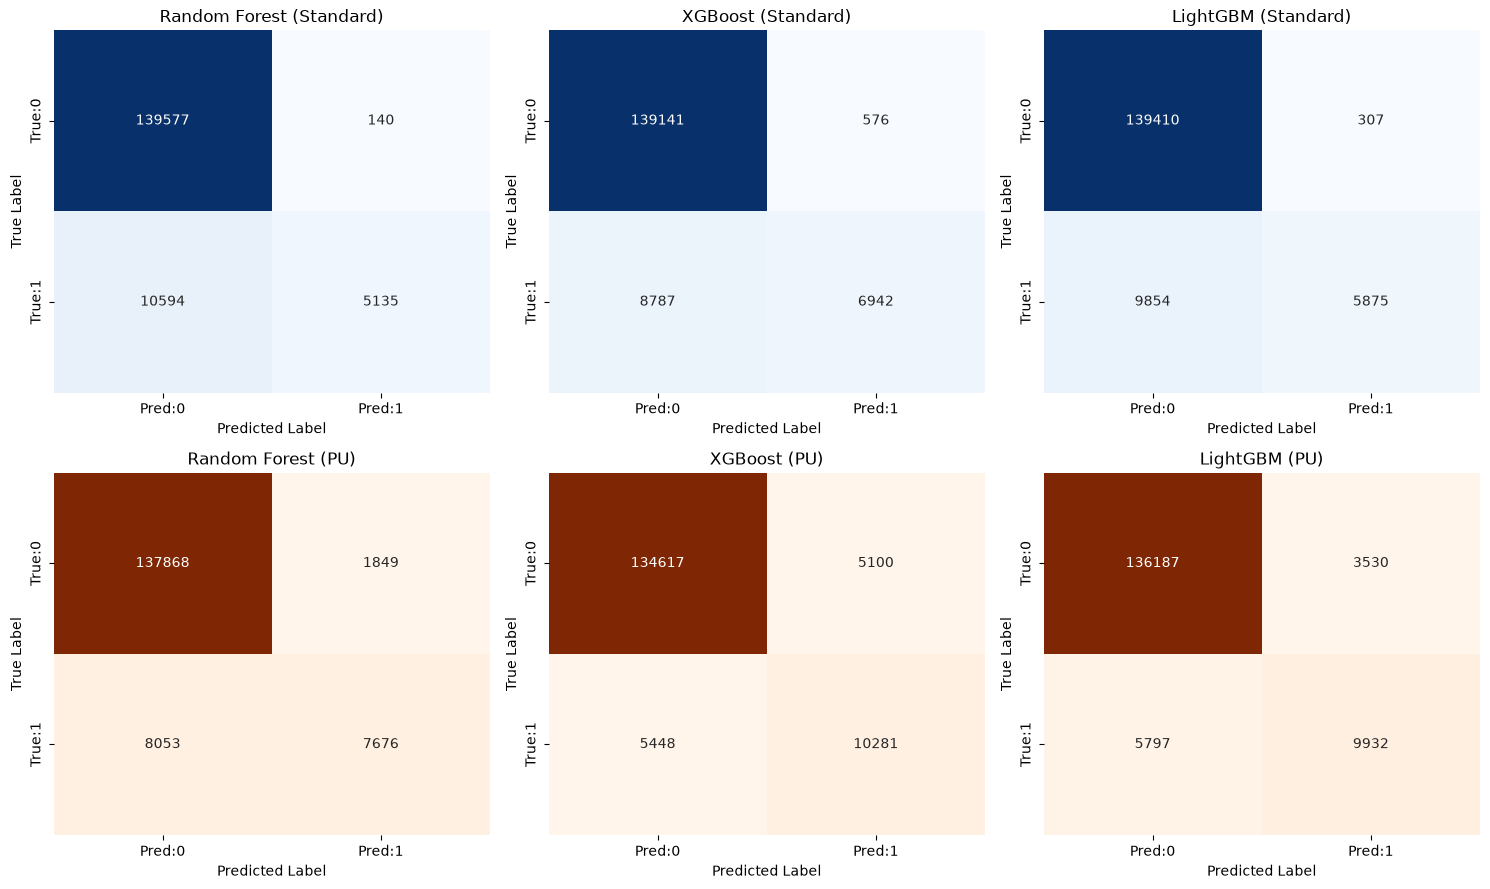

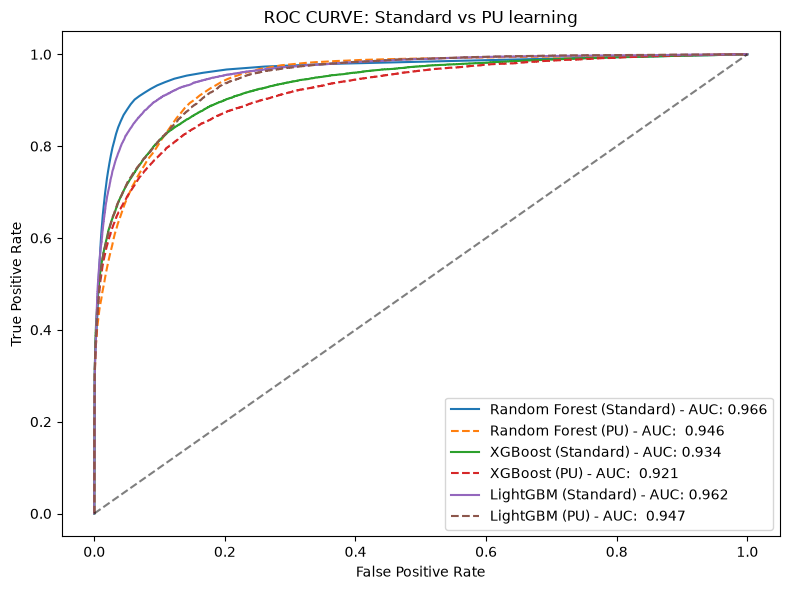

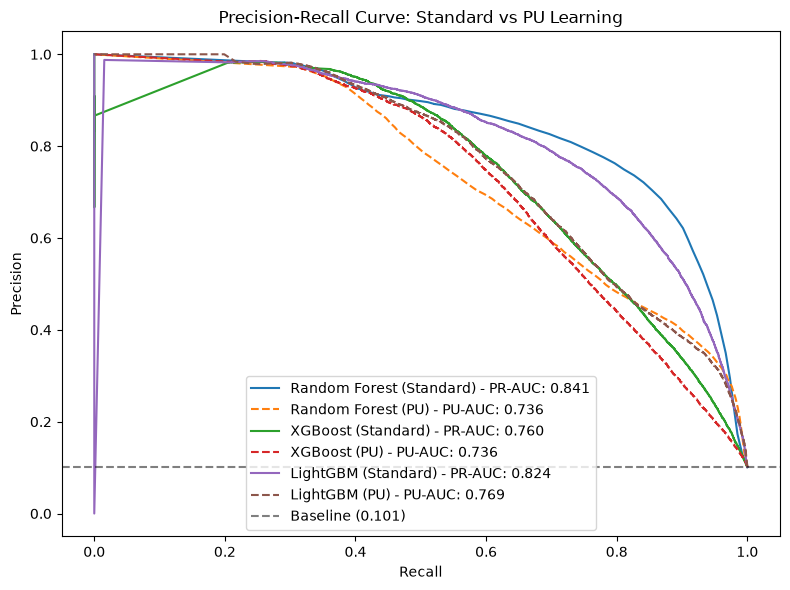

        Model        Type  Threshold  ROC-AUC  PR-AUC  Precision  Recall  F1-Score
Random Forest    Standard        0.8   0.9661  0.8413     0.9735  0.3265    0.4890
Random Forest PU Learning        0.8   0.9455  0.7364     0.8059  0.4880    0.6079
      XGBoost    Standard        0.8   0.9337  0.7600     0.9234  0.4414    0.5972
      XGBoost PU Learning        0.8   0.9214  0.7361     0.6684  0.6536    0.6609
     LightGBM    Standard        0.8   0.9622  0.8240     0.9503  0.3735    0.5363
     LightGBM PU Learning        0.8   0.9473  0.7692     0.7378  0.6314    0.6805


In [ ]:
import  xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, average_precision_score, precision_recall_curve
from sklearn.base import clone
#=================
base_models = {
    "Random Forest":RandomForestClassifier(
    random_state=42
),
"XGBoost": xgb.XGBClassifier(
    random_state=42
),
"LightGBM":lgb.LGBMClassifier(
    random_state = 42,
)
} 
threshold = 0.9
results =[]
fig_cm, axes_cm = plt.subplots(2, 3, figsize=(15, 9))
fig_roc, ax_roc = plt.subplots(figsize=(8,6))
fig_prc, ax_prc = plt.subplots(figsize=(8,6)) # 計算 PR-AUC / AP


for idx, (name, base_clf) in enumerate(base_models.items()):
    std_clf = clone(base_clf)
    std_clf.fit(X_train_final, y_train)

    y_prob_std= std_clf.predict_proba(X_test_final)[:, 1]
    y_pred_std = (y_prob_std >= threshold).astype(int)

    auc_std = roc_auc_score(y_test, y_prob_std)
    pr_auc_std = average_precision_score(y_test, y_prob_std)

    prec_std, rec_std, _ = precision_recall_curve(y_test, y_prob_std)
    ax_prc.plot(rec_std, prec_std, label=f'{name} (Standard) - PR-AUC: {pr_auc_std:.3f}')
    

    results.append({
        "Model":name, "Type":"Standard", "Threshold":threshold,
        "ROC-AUC": round(auc_std, 4),
        "PR-AUC": round(pr_auc_std, 4),
        "Precision": round(precision_score(y_test, y_pred_std, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred_std, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, y_pred_std, zero_division=0), 4)
    })

    fpr_std, tpr_std, _ = roc_curve(y_test, y_prob_std)
    ax_roc.plot(fpr_std, tpr_std, label=f"{name} (Standard) - AUC: {auc_std:.3f}")

    cm = confusion_matrix(y_test, y_pred_std)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[0, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])

    axes_cm[0, idx].set_title(f"{name} (Standard)")
    axes_cm[0, idx].set_xlabel(f"Predicted Label")
    axes_cm[0, idx].set_ylabel(f"True Label")

    #============= Pu model
    n_bags= 30
    pu_clf= bagging_rf(n_bags,clone(base_clf), X_train_final, y_train)

    y_prob_pu =  pu_clf.predict_proba(X_test_final)[:, 1]
    y_pred_pu = (y_prob_pu >= threshold).astype(int)

    auc_pu = roc_auc_score(y_test, y_prob_pu)
    pr_auc_pu = average_precision_score(y_test, y_prob_pu)
    
    results.append({
        "Model": name, "Type": "PU Learning", "Threshold":threshold,
        "ROC-AUC": round(auc_pu, 4),
        "PR-AUC":round (pr_auc_pu, 4),
        "Precision": round(precision_score(y_test, y_pred_pu, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred_pu, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, y_pred_pu, zero_division=0 ), 4)
    })

    fpr_pu, tpr_pu, _ = roc_curve(y_test, y_prob_pu)
    ax_roc.plot(fpr_pu, tpr_pu, linestyle='--', label=f'{name} (PU) - AUC: {auc_pu: .3f}')

    prec_pu, rec_pu, _ = precision_recall_curve(y_test, y_prob_pu)
    ax_prc.plot(rec_pu, prec_pu, linestyle='--', label=f'{name} (PU) - PU-AUC:{pr_auc_pu: .3f}')

    cm = confusion_matrix(y_test, y_pred_pu)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes_cm[1, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])
    axes_cm[1, idx].set_title(f"{name} (PU)")
    axes_cm[1, idx].set_xlabel("Predicted Label")
    axes_cm[1, idx].set_ylabel("True Label")

ax_roc.plot([0, 1], [0,1], 'k--', alpha=0.5)
ax_roc.set_title("ROC CURVE: Standard vs PU learning")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend()

fig_roc.tight_layout()
fig_roc.savefig("img/PU_ROC_Comparison.png")



baseline_pr = np.sum(y_test == 1) / len(y_test)
ax_prc.axhline(y=baseline_pr, color='k', linestyle='--', alpha=0.5, label=f'Baseline ({baseline_pr:.3f})')
ax_prc.set_title("Precision-Recall Curve: Standard vs PU Learning")
ax_prc.set_xlabel("Recall")
ax_prc.set_ylabel("Precision")
ax_prc.legend()
fig_prc.tight_layout()
fig_prc.savefig("img/PU_PRC_Comparison.png")


fig_cm.tight_layout()
fig_cm.savefig("img/PU_Confusion_Matrix_Comparison.png")


plt.show()


df_metrics = pd.DataFrame(results)
print(df_metrics.to_string(index=False))
df_metrics.to_csv("img/PU_vs_Standard_Metrics.csv", index=False)
#===========

Maybe threshold 0.8 is too low?


### grids search bags start from 5


 Grid Search:Random Forest
Fitting 3 folds for each of 2 candidates, totalling 6 fits
[CV] END .....................max_depth=10, n_estimators=100; total time=  20.2s
[CV] END .....................max_depth=10, n_estimators=100; total time=  20.3s
[CV] END .....................max_depth=10, n_estimators=100; total time=  20.4s
[CV] END .....................max_depth=20, n_estimators=100; total time=  37.7s
[CV] END .....................max_depth=20, n_estimators=100; total time=  37.8s
[CV] END .....................max_depth=20, n_estimators=100; total time=  38.1s
Best parameter combination: {'max_depth': 20, 'n_estimators': 100}
Number of Bag: 5
Positive: 21442
Unlabeled: 600338

 PU training data, Bag 1/5 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 2/5 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 3/5 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 4/5 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 5/5 Positive = 21442, Unlabele

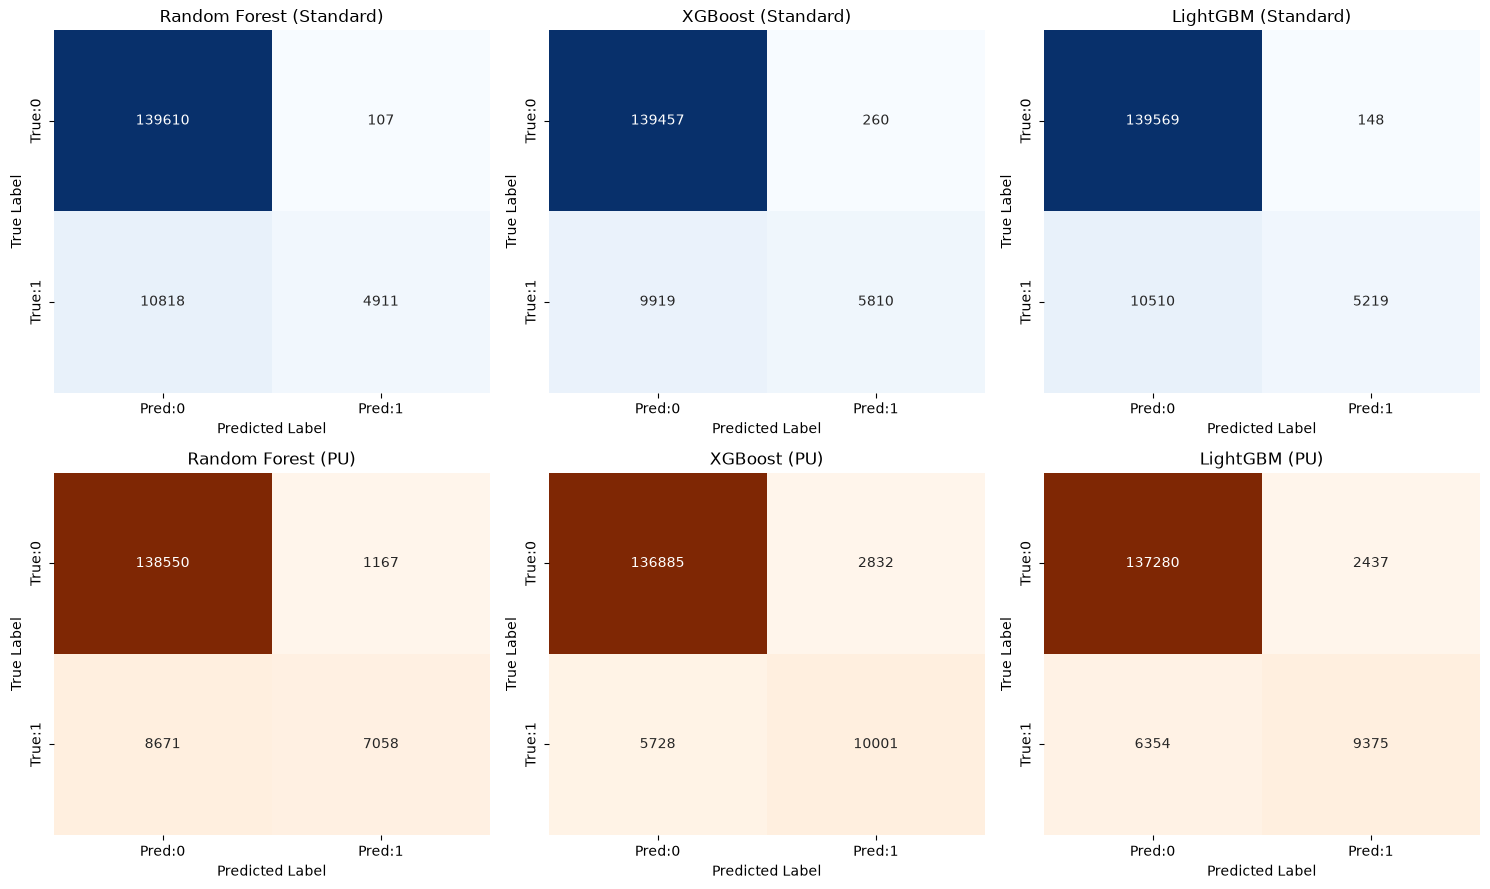

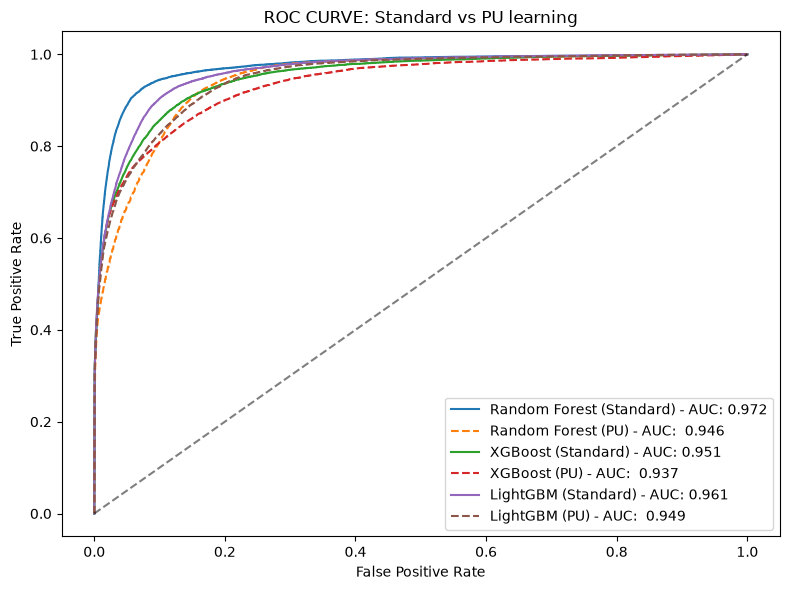

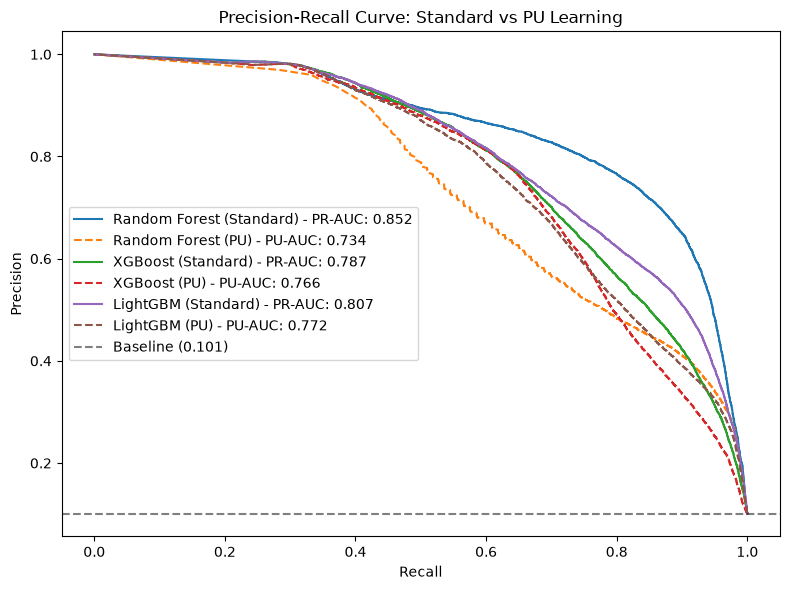

        Model        Type  Threshold  ROC-AUC  PR-AUC  Precision  Recall  F1-Score
Random Forest    Standard       0.85   0.9720  0.8516     0.9787  0.3122    0.4734
Random Forest PU Learning       0.85   0.9455  0.7340     0.8581  0.4487    0.5893
      XGBoost    Standard       0.85   0.9507  0.7872     0.9572  0.3694    0.5331
      XGBoost PU Learning       0.85   0.9366  0.7658     0.7793  0.6358    0.7003
     LightGBM    Standard       0.85   0.9612  0.8065     0.9724  0.3318    0.4948
     LightGBM PU Learning       0.85   0.9490  0.7719     0.7937  0.5960    0.6808


In [ ]:
import  xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, average_precision_score, precision_recall_curve
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.base import clone
#=================
param_grids = {
    "Random Forest":{
        'n_estimators':[100],
        'max_depth': [10, 20],
        #'min_samples_split':[2, 5],
        #'class_weight':['balanced']
        },
    "XGBoost":{
        'n_estimators':[100, 200],
        'max_depth':[3, 5],
        'learning_rate':[0.05, 0.1]
       # 'subample':[0.8],
        #'colsample_bytree':[0.8]
        },
    "LightGBM":{
        'n_estimators':[100, 200],
        'max_depth':[-1, 10],
        'learning_rate':[0.05, 0.1],
        #'verbose':[-1]
    }
}
base_models = {
    "Random Forest":RandomForestClassifier(random_state=42),
    "XGBoost":xgb.XGBClassifier(random_state=42),
    "LightGBM":lgb.LGBMClassifier(random_state = 42)
} 

threshold = 0.85
results =[]
fig_cm, axes_cm = plt.subplots(2, 3, figsize=(15, 9))
fig_roc, ax_roc = plt.subplots(figsize=(8,6))
fig_prc, ax_prc = plt.subplots(figsize=(8,6)) # calculate PR-AUC / AP
best_fitted_models = {}
best_params_dict = {}
best_score_dict = {}

for idx, (name, base_clf) in enumerate(base_models.items()):
    print(f" Grid Search:{name}")
    X_sub, _, y_sub, _ = train_test_split(
        X_train_final, y_train,
        train_size=0.1,
        random_state=42,
        stratify=y_train
    )
    grid_search = GridSearchCV(
        estimator = clone(base_clf),
        param_grid = param_grids[name],
        cv = 3,
        scoring = 'average_precision',
        n_jobs=-1,
        verbose=2
        
    )
    grid_search.fit(X_sub, y_sub)

    best_params= grid_search.best_params_
    best_params_dict[name] = grid_search.best_params_
    best_score_dict[name] = grid_search.best_score_
    
    print(f"Best parameter combination: {best_params}")
    best_std_clf = clone(base_clf)
    best_std_clf.set_params(**best_params)
    best_std_clf.fit(X_train_final, y_train)

    best_fitted_models[name] = best_std_clf
    y_prob_std= best_std_clf.predict_proba(X_test_final)[:, 1]
    y_pred_std = (y_prob_std >= threshold).astype(int)

    auc_std = roc_auc_score(y_test, y_prob_std)
    pr_auc_std = average_precision_score(y_test, y_prob_std)

    prec_std, rec_std, _ = precision_recall_curve(y_test, y_prob_std)
    ax_prc.plot(rec_std, prec_std, label=f'{name} (Standard) - PR-AUC: {pr_auc_std:.3f}')
    

    results.append({
        "Model":name, "Type":"Standard", "Threshold":threshold,
        "ROC-AUC": round(auc_std, 4),
        "PR-AUC": round(pr_auc_std, 4),
        "Precision": round(precision_score(y_test, y_pred_std, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred_std, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, y_pred_std, zero_division=0), 4)
    })

    fpr_std, tpr_std, _ = roc_curve(y_test, y_prob_std)
    ax_roc.plot(fpr_std, tpr_std, label=f"{name} (Standard) - AUC: {auc_std:.3f}")

    cm = confusion_matrix(y_test, y_pred_std)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[0, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])

    axes_cm[0, idx].set_title(f"{name} (Standard)")
    axes_cm[0, idx].set_xlabel(f"Predicted Label")
    axes_cm[0, idx].set_ylabel(f"True Label")

    #============= Pu model
    n_bags= 5
    pu_clf= bagging_rf(n_bags,clone(best_std_clf), X_train_final, y_train)

    y_prob_pu =  pu_clf.predict_proba(X_test_final)[:, 1]
    y_pred_pu = (y_prob_pu >= threshold).astype(int)

    auc_pu = roc_auc_score(y_test, y_prob_pu)
    pr_auc_pu = average_precision_score(y_test, y_prob_pu)
    
    results.append({
        "Model": name, "Type": "PU Learning", "Threshold":threshold,
        "ROC-AUC": round(auc_pu, 4),
        "PR-AUC":round (pr_auc_pu, 4),
        "Precision": round(precision_score(y_test, y_pred_pu, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred_pu, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, y_pred_pu, zero_division=0 ), 4)
    })

    fpr_pu, tpr_pu, _ = roc_curve(y_test, y_prob_pu)
    ax_roc.plot(fpr_pu, tpr_pu, linestyle='--', label=f'{name} (PU) - AUC: {auc_pu: .3f}')

    prec_pu, rec_pu, _ = precision_recall_curve(y_test, y_prob_pu)
    ax_prc.plot(rec_pu, prec_pu, linestyle='--', label=f'{name} (PU) - PU-AUC:{pr_auc_pu: .3f}')

    cm = confusion_matrix(y_test, y_pred_pu)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes_cm[1, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])
    axes_cm[1, idx].set_title(f"{name} (PU)")
    axes_cm[1, idx].set_xlabel("Predicted Label")
    axes_cm[1, idx].set_ylabel("True Label")

ax_roc.plot([0, 1], [0,1], 'k--', alpha=0.5)
ax_roc.set_title("ROC CURVE: Standard vs PU learning")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend()

fig_roc.tight_layout()
fig_roc.savefig("img/PU_ROC_Comparison.png")



baseline_pr = np.sum(y_test == 1) / len(y_test)
ax_prc.axhline(y=baseline_pr, color='k', linestyle='--', alpha=0.5, label=f'Baseline ({baseline_pr:.3f})')
ax_prc.set_title("Precision-Recall Curve: Standard vs PU Learning")
ax_prc.set_xlabel("Recall")
ax_prc.set_ylabel("Precision")
ax_prc.legend()
fig_prc.tight_layout()
fig_prc.savefig("img/PU_PRC_Comparison_grid_bag5.png")


fig_cm.tight_layout()
fig_cm.savefig("img/PU_Confusion_Matrix_Comparison_grid_bag5.png")


plt.show()


df_metrics = pd.DataFrame(results)
print(df_metrics.to_string(index=False))
df_metrics.to_csv("img/PU_vs_Standard_Metrics_grid_bag5.csv", index=False)
#===========


RF model peroforms well, set param as {'max_depth': 20, 'n_estimators': 100}
lighBGM takㄍs time,
tuning XGBOost first( it runs fast)


### hypertuning xgboost

 Grid Search:XGBoost
Fitting 3 folds for each of 9 candidates, totalling 27 fits
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=150; total time=   2.0s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=150; total time=   2.0s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=150; total time=   2.1s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=200; total time=   3.7s
[CV] END ...learning_rate=0.1, max_depth=5, n_estimators=150; total time=   3.7s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=200; total time=   3.8s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=200; total time=   4.1s
[CV] END ...learning_rate=0.1, max_depth=5, n_estimators=150; total time=   4.0s
[CV] END ...learning_rate=0.1, max_depth=5, n_estimators=150; total time=   4.1s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=300; total time=   4.7s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=300; total time=   5.2s
[CV] END ...learning_rate=0.

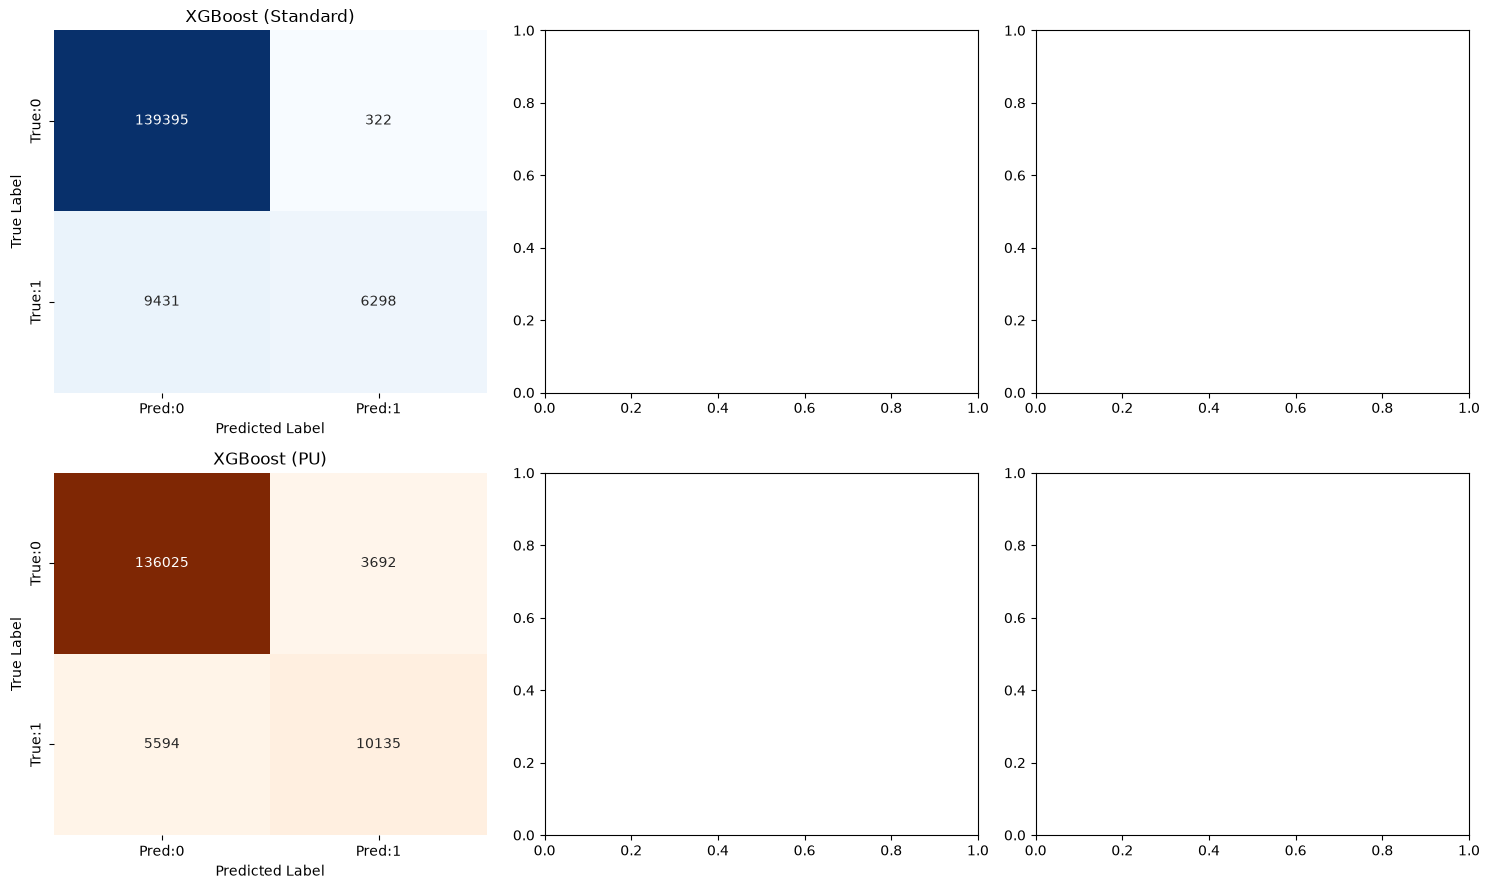

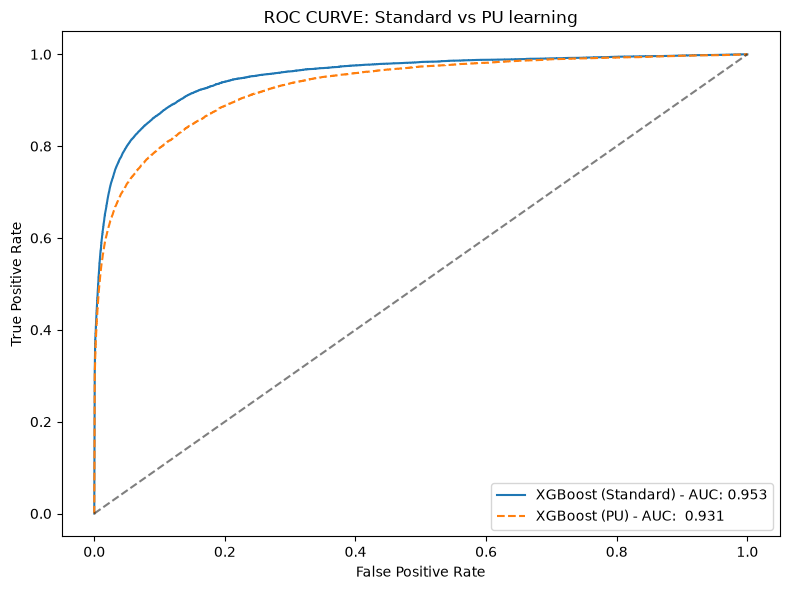

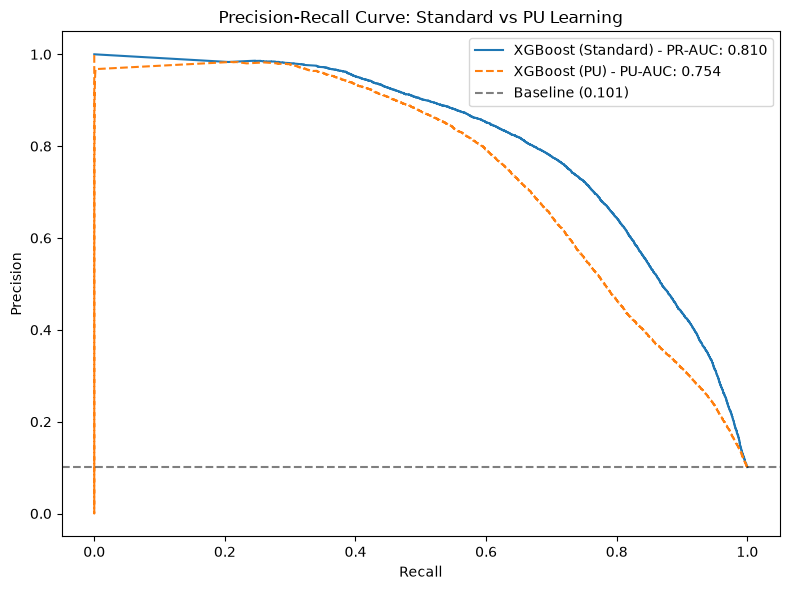

  Model        Type  Threshold  ROC-AUC  PR-AUC  Precision  Recall  F1-Score
XGBoost    Standard       0.85   0.9532  0.8101     0.9514  0.4004    0.5636
XGBoost PU Learning       0.85   0.9306  0.7541     0.7330  0.6444    0.6858


In [ ]:
import  xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, average_precision_score, precision_recall_curve
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.base import clone
#=================
param_grids = {
    "Random Forest":{
        'n_estimators':[100],
        'max_depth': [10, 20],
        #'min_samples_split':[2, 5],
        #'class_weight':['balanced']
        },
    "XGBoost":{
        'n_estimators':[150, 200, 300],
        'max_depth':[4, 5, 6],
        'learning_rate':[0.1]
       # 'subample':[0.8],
        #'colsample_bytree':[0.8]
        },
    "LightGBM":{
        'n_estimators':[100, 200],
        'max_depth':[-1, 10],
        'learning_rate':[0.05, 0.1],
        #'verbose':[-1]
    }
}
base_models = {
    #"Random Forest":RandomForestClassifier(random_state=42),
    "XGBoost":xgb.XGBClassifier(random_state=42),
    #"LightGBM":lgb.LGBMClassifier(random_state = 42)
} 

threshold = 0.85
results =[]
fig_cm, axes_cm = plt.subplots(2, 3, figsize=(15, 9))
fig_roc, ax_roc = plt.subplots(figsize=(8,6))
fig_prc, ax_prc = plt.subplots(figsize=(8,6)) # calculate PR-AUC / AP
best_fitted_models = {}
best_params_dict = {}
best_score_dict = {}

for idx, (name, base_clf) in enumerate(base_models.items()):
    print(f" Grid Search:{name}")
    X_sub, _, y_sub, _ = train_test_split(
        X_train_final, y_train,
        train_size=0.1,
        random_state=42,
        stratify=y_train
    )
    grid_search = GridSearchCV(
        estimator = clone(base_clf),
        param_grid = param_grids[name],
        cv = 3,
        scoring = 'average_precision',
        n_jobs=-1,
        verbose=2
        
    )
    grid_search.fit(X_sub, y_sub)

    best_params= grid_search.best_params_
    best_params_dict[name] = grid_search.best_params_
    best_score_dict[name] = grid_search.best_score_
    
    print(f"Best parameter combination: {best_params}")
    best_std_clf = clone(base_clf)
    best_std_clf.set_params(**best_params)
    best_std_clf.fit(X_train_final, y_train)

    best_fitted_models[name] = best_std_clf
    y_prob_std= best_std_clf.predict_proba(X_test_final)[:, 1]
    y_pred_std = (y_prob_std >= threshold).astype(int)

    auc_std = roc_auc_score(y_test, y_prob_std)
    pr_auc_std = average_precision_score(y_test, y_prob_std)

    prec_std, rec_std, _ = precision_recall_curve(y_test, y_prob_std)
    ax_prc.plot(rec_std, prec_std, label=f'{name} (Standard) - PR-AUC: {pr_auc_std:.3f}')
    

    results.append({
        "Model":name, "Type":"Standard", "Threshold":threshold,
        "ROC-AUC": round(auc_std, 4),
        "PR-AUC": round(pr_auc_std, 4),
        "Precision": round(precision_score(y_test, y_pred_std, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred_std, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, y_pred_std, zero_division=0), 4)
    })

    fpr_std, tpr_std, _ = roc_curve(y_test, y_prob_std)
    ax_roc.plot(fpr_std, tpr_std, label=f"{name} (Standard) - AUC: {auc_std:.3f}")

    cm = confusion_matrix(y_test, y_pred_std)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[0, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])

    axes_cm[0, idx].set_title(f"{name} (Standard)")
    axes_cm[0, idx].set_xlabel(f"Predicted Label")
    axes_cm[0, idx].set_ylabel(f"True Label")

    #============= Pu model
    n_bags= 5
    pu_clf= bagging_rf(n_bags,clone(best_std_clf), X_train_final, y_train)

    y_prob_pu =  pu_clf.predict_proba(X_test_final)[:, 1]
    y_pred_pu = (y_prob_pu >= threshold).astype(int)

    auc_pu = roc_auc_score(y_test, y_prob_pu)
    pr_auc_pu = average_precision_score(y_test, y_prob_pu)
    
    results.append({
        "Model": name, "Type": "PU Learning", "Threshold":threshold,
        "ROC-AUC": round(auc_pu, 4),
        "PR-AUC":round (pr_auc_pu, 4),
        "Precision": round(precision_score(y_test, y_pred_pu, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred_pu, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, y_pred_pu, zero_division=0 ), 4)
    })

    fpr_pu, tpr_pu, _ = roc_curve(y_test, y_prob_pu)
    ax_roc.plot(fpr_pu, tpr_pu, linestyle='--', label=f'{name} (PU) - AUC: {auc_pu: .3f}')

    prec_pu, rec_pu, _ = precision_recall_curve(y_test, y_prob_pu)
    ax_prc.plot(rec_pu, prec_pu, linestyle='--', label=f'{name} (PU) - PU-AUC:{pr_auc_pu: .3f}')

    cm = confusion_matrix(y_test, y_pred_pu)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes_cm[1, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])
    axes_cm[1, idx].set_title(f"{name} (PU)")
    axes_cm[1, idx].set_xlabel("Predicted Label")
    axes_cm[1, idx].set_ylabel("True Label")

ax_roc.plot([0, 1], [0,1], 'k--', alpha=0.5)
ax_roc.set_title("ROC CURVE: Standard vs PU learning")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend()

fig_roc.tight_layout()
fig_roc.savefig("img/PU_ROC_Comparison_XGBOOST.png")



baseline_pr = np.sum(y_test == 1) / len(y_test)
ax_prc.axhline(y=baseline_pr, color='k', linestyle='--', alpha=0.5, label=f'Baseline ({baseline_pr:.3f})')
ax_prc.set_title("Precision-Recall Curve: Standard vs PU Learning")
ax_prc.set_xlabel("Recall")
ax_prc.set_ylabel("Precision")
ax_prc.legend()
fig_prc.tight_layout()
fig_prc.savefig("img/PU_PRC_Comparison_grid_bag5_XGBOOST.png")


fig_cm.tight_layout()
fig_cm.savefig("img/PU_Confusion_Matrix_Comparison_grid_bag5_XGBOOST.png")


plt.show()


df_metrics = pd.DataFrame(results)
print(df_metrics.to_string(index=False))
df_metrics.to_csv("img/PU_vs_Standard_Metrics_grid_bag5_XGBOOST.csv", index=False)
#===========Rf model 

### Different bags - with XGBOOST best param 

 Grid Search:XGBoost
Fitting 3 folds for each of 9 candidates, totalling 27 fits
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=150; total time=   1.7s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=150; total time=   1.7s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=150; total time=   2.0s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=200; total time=   2.3s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=200; total time=   2.1s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=200; total time=   2.3s
[CV] END ...learning_rate=0.1, max_depth=5, n_estimators=150; total time=   2.3s
[CV] END ...learning_rate=0.1, max_depth=5, n_estimators=150; total time=   2.3s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=300; total time=   3.2s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=300; total time=   3.2s
[CV] END ...learning_rate=0.1, max_depth=5, n_estimators=150; total time=   2.6s
[CV] END ...learning_rate=0.

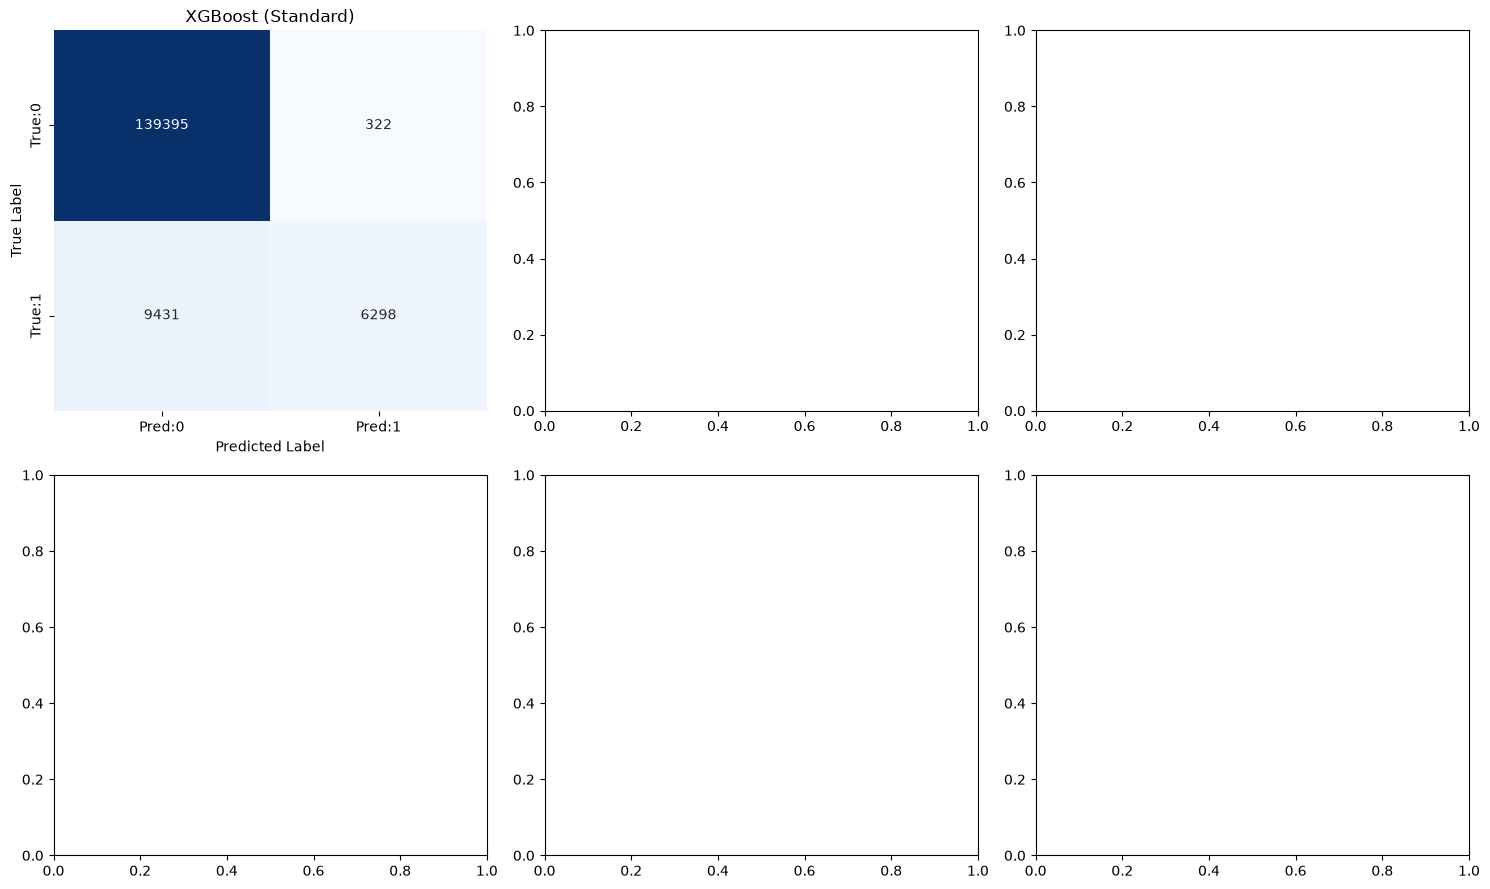

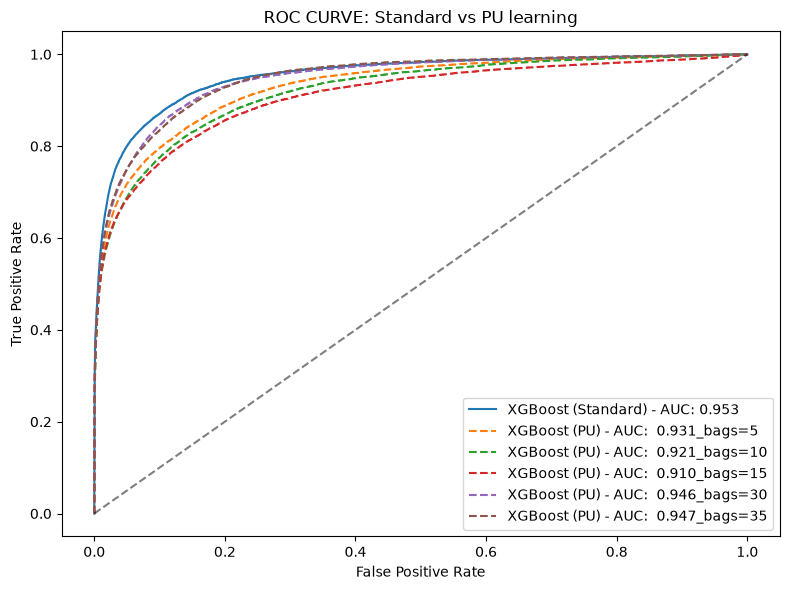

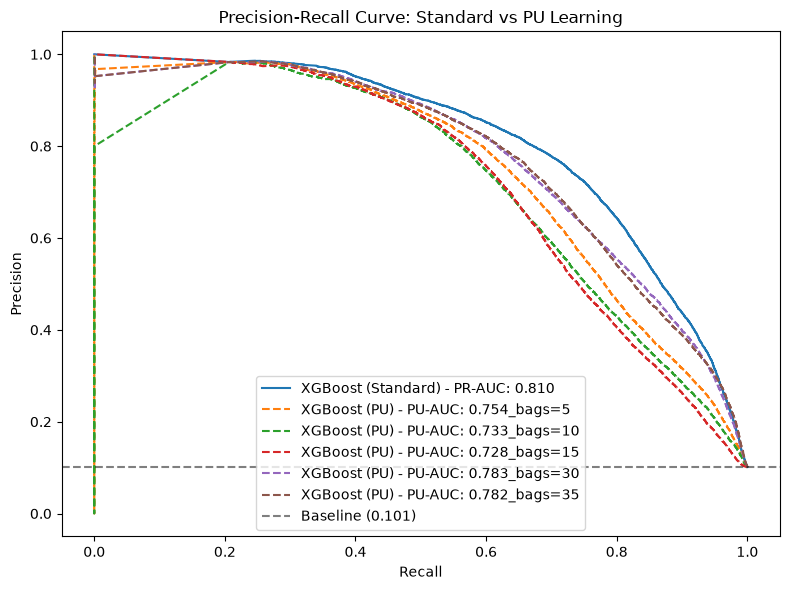

  Model        Type  Threshold  Bag  ROC-AUC  PR-AUC  Precision  Recall  F1-Score
XGBoost    Standard       0.85    0   0.9532  0.8101     0.9514  0.4004    0.5636
XGBoost PU Learning       0.85    5   0.9306  0.7541     0.7330  0.6444    0.6858
XGBoost PU Learning       0.85   10   0.9205  0.7335     0.6818  0.6431    0.6619
XGBoost PU Learning       0.85   15   0.9097  0.7282     0.7386  0.6121    0.6694
XGBoost PU Learning       0.85   30   0.9463  0.7827     0.7202  0.6817    0.7004
XGBoost PU Learning       0.85   35   0.9471  0.7820     0.7350  0.6778    0.7053


In [ ]:
import  xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, average_precision_score, precision_recall_curve
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.base import clone
#=================
n_bags=0
param_grids = {
    "Random Forest":{
        'n_estimators':[100],
        'max_depth': [10, 20],
        #'min_samples_split':[2, 5],
        #'class_weight':['balanced']
        },
    "XGBoost":{
        'n_estimators':[150, 200, 300],
        'max_depth':[4, 5, 6],
        'learning_rate':[0.1]
       # 'subample':[0.8],
        #'colsample_bytree':[0.8]
        },
    "LightGBM":{
        'n_estimators':[100, 200],
        'max_depth':[-1, 10],
        'learning_rate':[0.05, 0.1],
        #'verbose':[-1]
    }
}
base_models = {
    #"Random Forest":RandomForestClassifier(random_state=42),
    "XGBoost":xgb.XGBClassifier(random_state=42),
    #"LightGBM":lgb.LGBMClassifier(random_state = 42)
} 

threshold = 0.85
results =[]
fig_cm, axes_cm = plt.subplots(2, 3, figsize=(15, 9))
fig_roc, ax_roc = plt.subplots(figsize=(8,6))
fig_prc, ax_prc = plt.subplots(figsize=(8,6)) # calculate PR-AUC / AP
best_fitted_models = {}
best_params_dict = {}
best_score_dict = {}

for idx, (name, base_clf) in enumerate(base_models.items()):
    print(f" Grid Search:{name}")
    X_sub, _, y_sub, _ = train_test_split(
        X_train_final, y_train,
        train_size=0.1,
        random_state=42,
        stratify=y_train
    )
    grid_search = GridSearchCV(
        estimator = clone(base_clf),
        param_grid = param_grids[name],
        cv = 3,
        scoring = 'average_precision',
        n_jobs=-1,
        verbose=2
        
    )
    grid_search.fit(X_sub, y_sub)

    best_params= grid_search.best_params_
    best_params_dict[name] = grid_search.best_params_
    best_score_dict[name] = grid_search.best_score_
    
    print(f"Best parameter combination: {best_params}")
    best_std_clf = clone(base_clf)
    best_std_clf.set_params(**best_params)
    best_std_clf.fit(X_train_final, y_train)

    best_fitted_models[name] = best_std_clf
    y_prob_std= best_std_clf.predict_proba(X_test_final)[:, 1]
    y_pred_std = (y_prob_std >= threshold).astype(int)

    auc_std = roc_auc_score(y_test, y_prob_std)
    pr_auc_std = average_precision_score(y_test, y_prob_std)

    prec_std, rec_std, _ = precision_recall_curve(y_test, y_prob_std)
    ax_prc.plot(rec_std, prec_std, label=f'{name} (Standard) - PR-AUC: {pr_auc_std:.3f}')
    

    results.append({
        "Model":name, "Type":"Standard", "Threshold":threshold,"Bag":n_bags,
        "ROC-AUC": round(auc_std, 4),
        "PR-AUC": round(pr_auc_std, 4),
        "Precision": round(precision_score(y_test, y_pred_std, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred_std, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, y_pred_std, zero_division=0), 4)
    })

    fpr_std, tpr_std, _ = roc_curve(y_test, y_prob_std)
    ax_roc.plot(fpr_std, tpr_std, label=f"{name} (Standard) - AUC: {auc_std:.3f}")

    cm = confusion_matrix(y_test, y_pred_std)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[0, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])

    axes_cm[0, idx].set_title(f"{name} (Standard)")
    axes_cm[0, idx].set_xlabel(f"Predicted Label")
    axes_cm[0, idx].set_ylabel(f"True Label")

    #============= Pu model
    bag_list = [5, 10, 15, 30, 35]
    for n_bags in bag_list:
        pu_clf= bagging_rf(n_bags,clone(best_std_clf), X_train_final, y_train)

        y_prob_pu =  pu_clf.predict_proba(X_test_final)[:, 1]
        y_pred_pu = (y_prob_pu >= threshold).astype(int)

        auc_pu = roc_auc_score(y_test, y_prob_pu)
        pr_auc_pu = average_precision_score(y_test, y_prob_pu)
        
        results.append({
            "Model": name, "Type": "PU Learning", "Threshold":threshold,"Bag":n_bags,
            "ROC-AUC": round(auc_pu, 4),
            "PR-AUC":round (pr_auc_pu, 4),
            "Precision": round(precision_score(y_test, y_pred_pu, zero_division=0), 4),
            "Recall": round(recall_score(y_test, y_pred_pu, zero_division=0), 4),
            "F1-Score": round(f1_score(y_test, y_pred_pu, zero_division=0 ), 4)
        })

        fpr_pu, tpr_pu, _ = roc_curve(y_test, y_prob_pu)
        ax_roc.plot(fpr_pu, tpr_pu, linestyle='--', label=f'{name} (PU) - AUC: {auc_pu: .3f}_bags={n_bags}')

        prec_pu, rec_pu, _ = precision_recall_curve(y_test, y_prob_pu)
        ax_prc.plot(rec_pu, prec_pu, linestyle='--', label=f'{name} (PU) - PU-AUC:{pr_auc_pu: .3f}_bags={n_bags}')

    #cm = confusion_matrix(y_test, y_pred_pu)
    #sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes_cm[1, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])
    #xes_cm[1, idx].set_title(f"{name} (PU)")
    #axes_cm[1, idx].set_xlabel("Predicted Label")
    #axes_cm[1, idx].set_ylabel("True Label")

ax_roc.plot([0, 1], [0,1], 'k--', alpha=0.5)
ax_roc.set_title("ROC CURVE: Standard vs PU learning")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend()

fig_roc.tight_layout()
fig_roc.savefig("img/PU_ROC_Comparison_XGBOOST_bag_compar.png")



baseline_pr = np.sum(y_test == 1) / len(y_test)
ax_prc.axhline(y=baseline_pr, color='k', linestyle='--', alpha=0.5, label=f'Baseline ({baseline_pr:.3f})')
ax_prc.set_title("Precision-Recall Curve: Standard vs PU Learning")
ax_prc.set_xlabel("Recall")
ax_prc.set_ylabel("Precision")
ax_prc.legend()
fig_prc.tight_layout()
fig_prc.savefig("img/PU_PRC_Comparison_XGBOOST_bag_compar.png")


fig_cm.tight_layout()
fig_cm.savefig("img/PU_Confusion_Matrix_Comparison_XGBOOST_bag_compar.png")


plt.show()


df_metrics = pd.DataFrame(results)
print(df_metrics.to_string(index=False))
df_metrics.to_csv("img/PU_vs_Standard_Metrics_XGBOOST_bag_compar.csv", index=False)
#===========Rf model 

### 30 bags with XGBoost try different threshold

 Grid Search:XGBoost
Fitting 3 folds for each of 9 candidates, totalling 27 fits
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=150; total time=   1.8s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=150; total time=   1.9s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=150; total time=   1.9s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=200; total time=   2.4s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=200; total time=   2.4s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=200; total time=   2.4s
[CV] END ...learning_rate=0.1, max_depth=5, n_estimators=150; total time=   2.4s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=300; total time=   3.5s
[CV] END ...learning_rate=0.1, max_depth=5, n_estimators=150; total time=   3.3s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=300; total time=   4.0s
[CV] END ...learning_rate=0.1, max_depth=5, n_estimators=150; total time=   3.4s
[CV] END ...learning_rate=0.

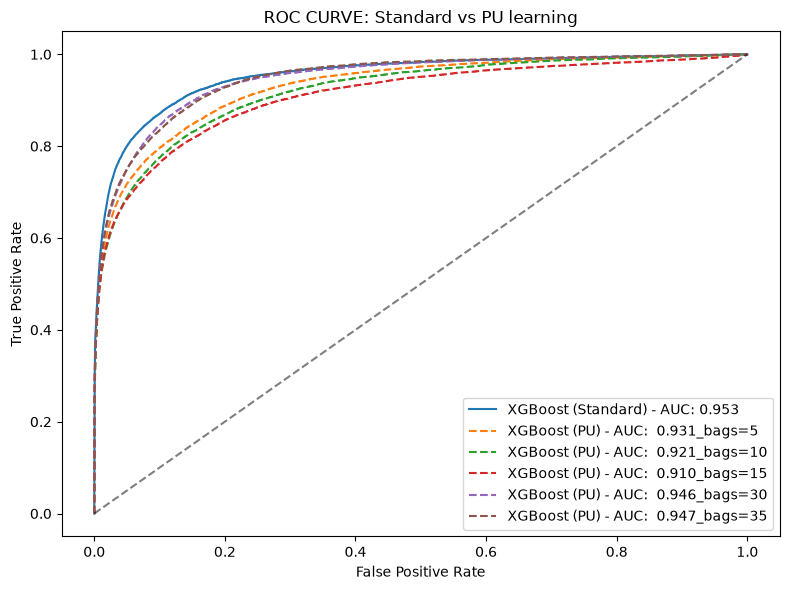

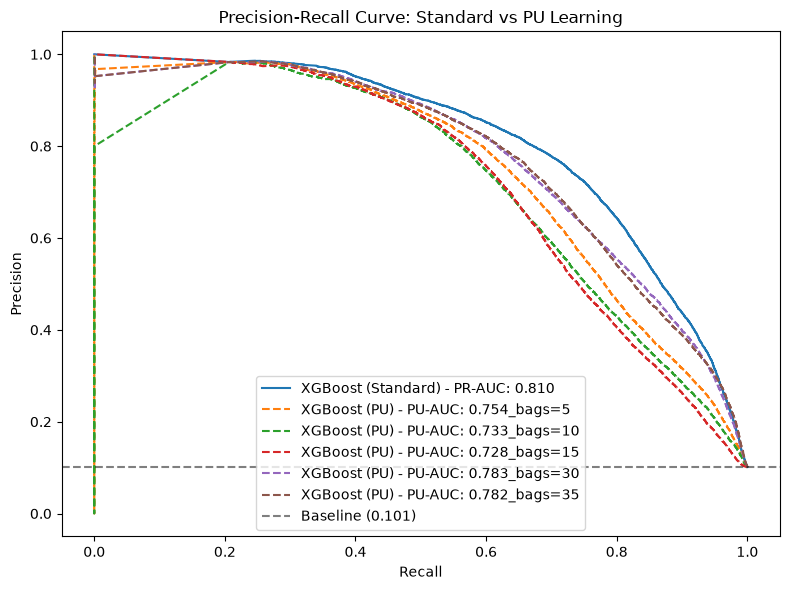

  Model        Type  Threshold  Bag  ROC-AUC  PR-AUC  Precision  Recall  F1-Score
XGBoost    Standard       0.50    0   0.9532  0.8101     0.8834  0.5455    0.6745
XGBoost    Standard       0.51    0   0.9532  0.8101     0.8860  0.5417    0.6723
XGBoost    Standard       0.52    0   0.9532  0.8101     0.8878  0.5368    0.6691
XGBoost    Standard       0.53    0   0.9532  0.8101     0.8889  0.5326    0.6661
XGBoost    Standard       0.54    0   0.9532  0.8101     0.8911  0.5285    0.6635
XGBoost    Standard       0.55    0   0.9532  0.8101     0.8926  0.5249    0.6611
XGBoost    Standard       0.56    0   0.9532  0.8101     0.8946  0.5209    0.6585
XGBoost    Standard       0.57    0   0.9532  0.8101     0.8960  0.5168    0.6555
XGBoost    Standard       0.58    0   0.9532  0.8101     0.8986  0.5127    0.6529
XGBoost    Standard       0.59    0   0.9532  0.8101     0.8999  0.5078    0.6492
XGBoost    Standard       0.60    0   0.9532  0.8101     0.9010  0.5036    0.6461
XGBoost    Stand

In [ ]:
import  xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, average_precision_score, precision_recall_curve
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.base import clone
#=================
n_bags=0
param_grids = {
    "Random Forest":{
        'n_estimators':[100],
        'max_depth': [10, 20],
        #'min_samples_split':[2, 5],
        #'class_weight':['balanced']
        },
    "XGBoost":{
        'n_estimators':[150, 200, 300],
        'max_depth':[4, 5, 6],
        'learning_rate':[0.1]
       # 'subample':[0.8],
        #'colsample_bytree':[0.8]
        },
    "LightGBM":{
    'learning_rate': 0.1, 
    'max_depth': 6, 
    'n_estimators': 300
        #'verbose':[-1]
    }
}
base_models = {
    #"Random Forest":RandomForestClassifier(random_state=42),
    "XGBoost":xgb.XGBClassifier(random_state=42),
    #"LightGBM":lgb.LGBMClassifier(random_state = 42)
} 

threshold = 0.85
results =[]
#fig_cm, axes_cm = plt.subplots(2, 3, figsize=(15, 9))
fig_roc, ax_roc = plt.subplots(figsize=(8,6))
fig_prc, ax_prc = plt.subplots(figsize=(8,6)) # calculate PR-AUC / AP
best_fitted_models = {}
best_params_dict = {}
best_score_dict = {}
threshold_list= np.arange(0.5, 0.951, 0.01)
for idx, (name, base_clf) in enumerate(base_models.items()):
    print(f" Grid Search:{name}")
    X_sub, _, y_sub, _ = train_test_split(
        X_train_final, y_train,
        train_size=0.1,
        random_state=42,
        stratify=y_train
    )
    grid_search = GridSearchCV(
        estimator = clone(base_clf),
        param_grid = param_grids[name],
        cv = 3,
        scoring = 'average_precision',
        n_jobs=-1,
        verbose=2
        
    )
    grid_search.fit(X_sub, y_sub)

    best_params= grid_search.best_params_
    best_params_dict[name] = grid_search.best_params_
    best_score_dict[name] = grid_search.best_score_
    
    print(f"Best parameter combination: {best_params}")
    best_std_clf = clone(base_clf)
    best_std_clf.set_params(**best_params)
    best_std_clf.fit(X_train_final, y_train)

    best_fitted_models[name] = best_std_clf
    y_prob_std= best_std_clf.predict_proba(X_test_final)[:, 1]

    for threshold in threshold_list:
        y_pred_std = (y_prob_std >= threshold).astype(int)

        auc_std = roc_auc_score(y_test, y_prob_std)
        pr_auc_std = average_precision_score(y_test, y_prob_std)


        

        results.append({
            "Model":name, "Type":"Standard", "Threshold":threshold,"Bag":n_bags,
            "ROC-AUC": round(auc_std, 4),
            "PR-AUC": round(pr_auc_std, 4),
            "Precision": round(precision_score(y_test, y_pred_std, zero_division=0), 4),
            "Recall": round(recall_score(y_test, y_pred_std, zero_division=0), 4),
            "F1-Score": round(f1_score(y_test, y_pred_std, zero_division=0), 4)
        })
    prec_std, rec_std, _ = precision_recall_curve(y_test, y_prob_std)
    ax_prc.plot(rec_std, prec_std, label=f'{name} (Standard) - PR-AUC: {pr_auc_std:.3f}')

    fpr_std, tpr_std, _ = roc_curve(y_test, y_prob_std)
    ax_roc.plot(fpr_std, tpr_std, label=f"{name} (Standard) - AUC: {auc_std:.3f}")

        #cm = confusion_matrix(y_test, y_pred_std)
        #sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[0, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])

        #axes_cm[0, idx].set_title(f"{name} (Standard)")
        #axes_cm[0, idx].set_xlabel(f"Predicted Label")
        #axes_cm[0, idx].set_ylabel(f"True Label")

    #============= Pu model
    bag_list = [5, 10, 15, 30, 35]
    for n_bags in bag_list:
        pu_clf= bagging_rf(n_bags,clone(best_std_clf), X_train_final, y_train)
        y_prob_pu =  pu_clf.predict_proba(X_test_final)[:, 1]
        for threshold in threshold_list:
            y_pred_pu = (y_prob_pu >= threshold).astype(int)

            auc_pu = roc_auc_score(y_test, y_prob_pu)
            pr_auc_pu = average_precision_score(y_test, y_prob_pu)
            
            results.append({
                "Model": name, "Type": "PU Learning", "Threshold":threshold,"Bag":n_bags,
                "ROC-AUC": round(auc_pu, 4),
                "PR-AUC":round (pr_auc_pu, 4),
                "Precision": round(precision_score(y_test, y_pred_pu, zero_division=0), 4),
                "Recall": round(recall_score(y_test, y_pred_pu, zero_division=0), 4),
                "F1-Score": round(f1_score(y_test, y_pred_pu, zero_division=0 ), 4)
            })

        fpr_pu, tpr_pu, _ = roc_curve(y_test, y_prob_pu)
        ax_roc.plot(fpr_pu, tpr_pu, linestyle='--', label=f'{name} (PU) - AUC: {auc_pu: .3f}_bags={n_bags}')

        prec_pu, rec_pu, _ = precision_recall_curve(y_test, y_prob_pu)
        ax_prc.plot(rec_pu, prec_pu, linestyle='--', label=f'{name} (PU) - PU-AUC:{pr_auc_pu: .3f}_bags={n_bags}')

    #cm = confusion_matrix(y_test, y_pred_pu)
    #sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes_cm[1, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])
    #xes_cm[1, idx].set_title(f"{name} (PU)")
    #axes_cm[1, idx].set_xlabel("Predicted Label")
    #axes_cm[1, idx].set_ylabel("True Label")

ax_roc.plot([0, 1], [0,1], 'k--', alpha=0.5)
ax_roc.set_title("ROC CURVE: Standard vs PU learning")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend()

fig_roc.tight_layout()
fig_roc.savefig("img/PU_ROC_Comparison_XGBOOST_bag_compar.png")



baseline_pr = np.sum(y_test == 1) / len(y_test)
ax_prc.axhline(y=baseline_pr, color='k', linestyle='--', alpha=0.5, label=f'Baseline ({baseline_pr:.3f})')
ax_prc.set_title("Precision-Recall Curve: Standard vs PU Learning")
ax_prc.set_xlabel("Recall")
ax_prc.set_ylabel("Precision")
ax_prc.legend()
fig_prc.tight_layout()
fig_prc.savefig("img/PU_PRC_Comparison_XGBOOST_bag_compar.png")


#fig_cm.tight_layout()
#fig_cm.savefig("img/PU_Confusion_Matrix_Comparison_XGBOOST_bag_compar.png")


plt.show()


df_metrics = pd.DataFrame(results)
print(df_metrics.to_string(index=False))
df_metrics.to_csv("img/PU_vs_Standard_Metrics_XGBOOST_bag_compar.csv", index=False)
#===========Rf model 

#### light best parameter {'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 200} with different bags

[LightGBM] [Info] Number of positive: 21442, number of negative: 600338
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.060781 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7408
[LightGBM] [Info] Number of data points in the train set: 621780, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034485 -> initscore=-3.332141
[LightGBM] [Info] Start training from score -3.332141
Number of Bag: 5
Positive: 21442
Unlabeled: 600338

 PU training data, Bag 1/5 Positive = 21442, Unlabeled = 21442
[LightGBM] [Info] Number of positive: 21442, number of negative: 21442
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004424 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7430
[LightGBM] [Info] Number of data points in the train set: 42884, number of used features: 30
[LightGBM] [Info] [binary:Boo

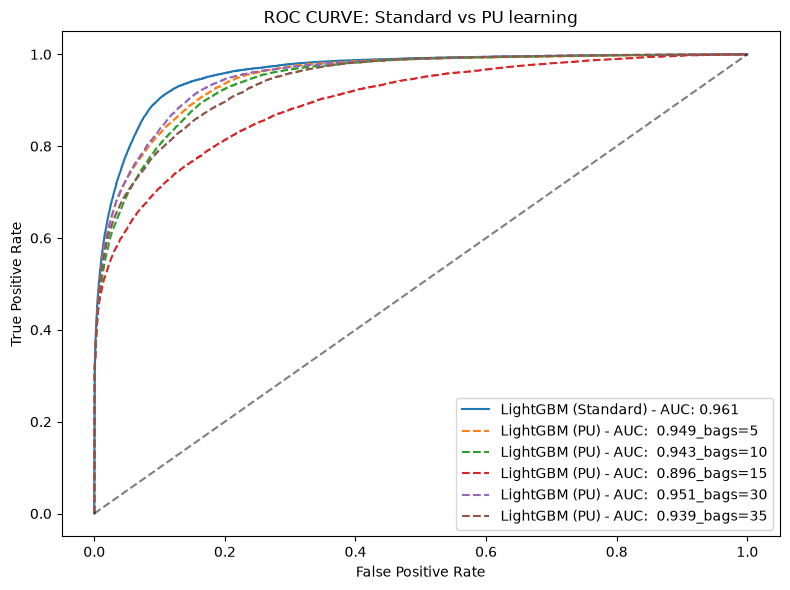

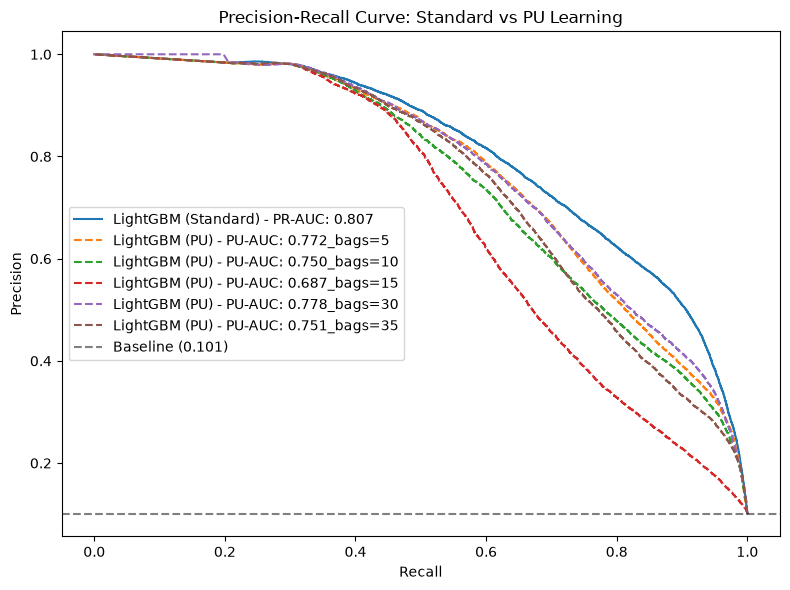

   Model        Type  Threshold  Bag  ROC-AUC  PR-AUC  Precision  Recall  F1-Score
LightGBM    Standard       0.50    0   0.9612  0.8065     0.9026  0.4792    0.6261
LightGBM    Standard       0.51    0   0.9612  0.8065     0.9055  0.4750    0.6231
LightGBM    Standard       0.52    0   0.9612  0.8065     0.9088  0.4709    0.6204
LightGBM    Standard       0.53    0   0.9612  0.8065     0.9111  0.4667    0.6173
LightGBM    Standard       0.54    0   0.9612  0.8065     0.9135  0.4630    0.6145
LightGBM    Standard       0.55    0   0.9612  0.8065     0.9158  0.4587    0.6113
LightGBM    Standard       0.56    0   0.9612  0.8065     0.9173  0.4550    0.6083
LightGBM    Standard       0.57    0   0.9612  0.8065     0.9194  0.4511    0.6053
LightGBM    Standard       0.58    0   0.9612  0.8065     0.9220  0.4465    0.6016
LightGBM    Standard       0.59    0   0.9612  0.8065     0.9235  0.4422    0.5980
LightGBM    Standard       0.60    0   0.9612  0.8065     0.9255  0.4376    0.5942
Ligh

In [32]:
import  xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, average_precision_score, precision_recall_curve
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.base import clone
#=================
n_bags=0

base_models = {
    #"Random Forest":RandomForestClassifier(random_state=42),
    #"XGBoost":xgb.XGBClassifier(random_state=42),
    "LightGBM":lgb.LGBMClassifier( learning_rate= 0.05, 
        max_depth= 10,    n_estimators= 200, random_state = 42)
} 

threshold = 0.85
results =[]
#fig_cm, axes_cm = plt.subplots(2, 3, figsize=(15, 9))
fig_roc, ax_roc = plt.subplots(figsize=(8,6))
fig_prc, ax_prc = plt.subplots(figsize=(8,6)) # calculate PR-AUC / AP
best_fitted_models = {}
best_params_dict = {}
best_score_dict = {}
threshold_list= np.arange(0.5, 0.951, 0.01)
for idx, (name, base_clf) in enumerate(base_models.items()):

    best_std_clf = clone(base_clf)
   # best_std_clf.set_params(**best_params)
    best_std_clf.fit(X_train_final, y_train)

    best_fitted_models[name] = best_std_clf
    y_prob_std= best_std_clf.predict_proba(X_test_final)[:, 1]

    for threshold in threshold_list:
        y_pred_std = (y_prob_std >= threshold).astype(int)

        auc_std = roc_auc_score(y_test, y_prob_std)
        pr_auc_std = average_precision_score(y_test, y_prob_std)


        results.append({
            "Model":name, "Type":"Standard", "Threshold":threshold,"Bag":n_bags,
            "ROC-AUC": round(auc_std, 4),
            "PR-AUC": round(pr_auc_std, 4),
            "Precision": round(precision_score(y_test, y_pred_std, zero_division=0), 4),
            "Recall": round(recall_score(y_test, y_pred_std, zero_division=0), 4),
            "F1-Score": round(f1_score(y_test, y_pred_std, zero_division=0), 4)
        })
    prec_std, rec_std, _ = precision_recall_curve(y_test, y_prob_std)
    ax_prc.plot(rec_std, prec_std, label=f'{name} (Standard) - PR-AUC: {pr_auc_std:.3f}')

    fpr_std, tpr_std, _ = roc_curve(y_test, y_prob_std)
    ax_roc.plot(fpr_std, tpr_std, label=f"{name} (Standard) - AUC: {auc_std:.3f}")

        #cm = confusion_matrix(y_test, y_pred_std)
        #sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[0, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])

        #axes_cm[0, idx].set_title(f"{name} (Standard)")
        #axes_cm[0, idx].set_xlabel(f"Predicted Label")
        #axes_cm[0, idx].set_ylabel(f"True Label")

    #============= Pu model
    bag_list = [5, 10, 15, 30, 35]
    for n_bags in bag_list:
        pu_clf= bagging_rf(n_bags,clone(best_std_clf), X_train_final, y_train)
        y_prob_pu =  pu_clf.predict_proba(X_test_final)[:, 1]
        for threshold in threshold_list:
            y_pred_pu = (y_prob_pu >= threshold).astype(int)

            auc_pu = roc_auc_score(y_test, y_prob_pu)
            pr_auc_pu = average_precision_score(y_test, y_prob_pu)
            
            results.append({
                "Model": name, "Type": "PU Learning", "Threshold":threshold,"Bag":n_bags,
                "ROC-AUC": round(auc_pu, 4),
                "PR-AUC":round (pr_auc_pu, 4),
                "Precision": round(precision_score(y_test, y_pred_pu, zero_division=0), 4),
                "Recall": round(recall_score(y_test, y_pred_pu, zero_division=0), 4),
                "F1-Score": round(f1_score(y_test, y_pred_pu, zero_division=0 ), 4)
            })

        fpr_pu, tpr_pu, _ = roc_curve(y_test, y_prob_pu)
        ax_roc.plot(fpr_pu, tpr_pu, linestyle='--', label=f'{name} (PU) - AUC: {auc_pu: .3f}_bags={n_bags}')

        prec_pu, rec_pu, _ = precision_recall_curve(y_test, y_prob_pu)
        ax_prc.plot(rec_pu, prec_pu, linestyle='--', label=f'{name} (PU) - PU-AUC:{pr_auc_pu: .3f}_bags={n_bags}')

    #cm = confusion_matrix(y_test, y_pred_pu)
    #sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes_cm[1, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])
    #xes_cm[1, idx].set_title(f"{name} (PU)")
    #axes_cm[1, idx].set_xlabel("Predicted Label")
    #axes_cm[1, idx].set_ylabel("True Label")

ax_roc.plot([0, 1], [0,1], 'k--', alpha=0.5)
ax_roc.set_title("ROC CURVE: Standard vs PU learning")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend()

fig_roc.tight_layout()
fig_roc.savefig("img/PU_ROC_Comparison_lightgb_bag_compar.png")



baseline_pr = np.sum(y_test == 1) / len(y_test)
ax_prc.axhline(y=baseline_pr, color='k', linestyle='--', alpha=0.5, label=f'Baseline ({baseline_pr:.3f})')
ax_prc.set_title("Precision-Recall Curve: Standard vs PU Learning")
ax_prc.set_xlabel("Recall")
ax_prc.set_ylabel("Precision")
ax_prc.legend()
fig_prc.tight_layout()
fig_prc.savefig("img/PU_PRC_Comparison_lightgbm_bag_compar.png")


#fig_cm.tight_layout()
#fig_cm.savefig("img/PU_Confusion_Matrix_Comparison_XGBOOST_bag_compar.png")


plt.show()


df_metrics = pd.DataFrame(results)
print(df_metrics.to_string(index=False))
df_metrics.to_csv("img/PU_vs_Standard_Metrics_lightgb_bag_compar.csv", index=False)
#===========Rf model 

### again, with best parameter, three model comparison
best para:
rf: 'max_depth': 20, 'n_estimators': 100
xgb:'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300
lightgbn:'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 200

In [11]:
from pulearn import ElkanotoPuClassifier
from sklearn.ensemble import RandomForestClassifier
tsfe = TSFE(feature_cols=feature_cols, feature_config=feature_config)
X_train_final = tsfe.fit_transform(X_train)

X_test_final = tsfe.transform(X_test)
X_train_final.columns.tolist()

['type',
 'pflow',
 'tmod',
 'CH4_rt',
 'CH4_w',
 'CH4_ht',
 'CH4_area',
 'CH4_skew',
 'CH4_start_time',
 'CH4_end_time',
 'CH4_start_level',
 'CH4_end_level',
 'is_air',
 'is_std',
 'last_std_CH4_ht',
 'last_air_CH4_ht',
 'last_std_CH4_area',
 'last_air_CH4_area',
 'last_std_CH4_rt',
 'last_air_CH4_rt',
 'last_std_CH4_start_level',
 'last_air_CH4_start_level',
 'CH4_ht_to_last_std_ratio',
 'CH4_ht_to_last_air_ratio',
 'CH4_area_to_last_std_ratio',
 'CH4_area_to_last_air_ratio',
 'CH4_rt_to_last_std_ratio',
 'CH4_rt_to_last_air_ratio',
 'CH4_start_level_to_last_std_ratio',
 'CH4_start_level_to_last_air_ratio',
 'duration_rt_ratio',
 'rt_position',
 'baseline_slope',
 'level_area_ratio',
 'CH4_area_diff_1',
 'CH4_area_diff_3',
 'CH4_area_diff_6',
 'CH4_area_diff_72',
 'CH4_ht_diff_1',
 'CH4_ht_diff_3',
 'CH4_ht_diff_6',
 'CH4_ht_diff_72',
 'CH4_w_diff_1',
 'CH4_w_diff_3',
 'CH4_w_diff_6',
 'CH4_w_diff_72',
 'CH4_rt_diff_1',
 'CH4_rt_diff_3',
 'CH4_rt_diff_6',
 'CH4_rt_diff_72',
 'CH4_ar

In [13]:
X_train_final, X_test_final = (X_train_final.drop(columns='type'), 
                               X_test_final.drop(columns='type'))

Number of Bag: 5
Positive: 21442
Unlabeled: 600338

 PU training data, Bag 1/5 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 2/5 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 3/5 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 4/5 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 5/5 Positive = 21442, Unlabeled = 21442
Number of Bag: 10
Positive: 21442
Unlabeled: 600338

 PU training data, Bag 1/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 2/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 3/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 4/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 5/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 6/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 7/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 8/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 9/10 Positive = 21442, Unlabeled 

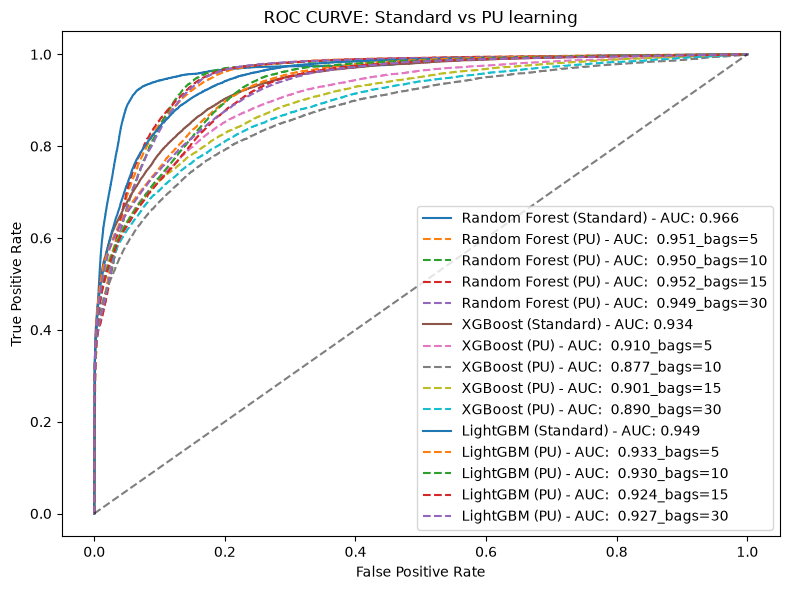

/home/ellie/research_project/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


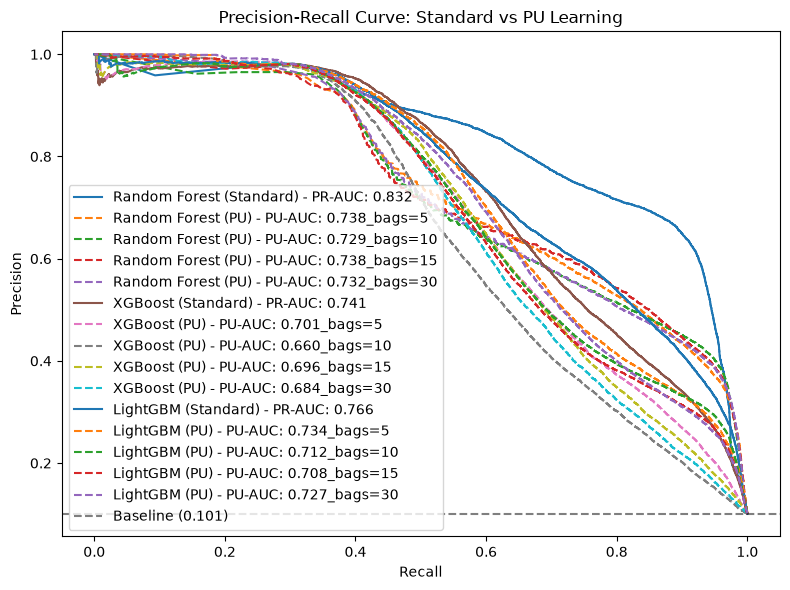

        Model        Type  Threshold  Bag  ROC-AUC  PR-AUC  Precision  Recall  F1-Score
Random Forest    Standard       0.50    0   0.9659  0.8318     0.9161  0.4265    0.5820
Random Forest    Standard       0.51    0   0.9659  0.8318     0.9186  0.4219    0.5782
Random Forest    Standard       0.52    0   0.9659  0.8318     0.9207  0.4166    0.5736
Random Forest    Standard       0.53    0   0.9659  0.8318     0.9235  0.4103    0.5682
Random Forest    Standard       0.54    0   0.9659  0.8318     0.9267  0.4053    0.5640
Random Forest    Standard       0.55    0   0.9659  0.8318     0.9288  0.4005    0.5597
Random Forest    Standard       0.56    0   0.9659  0.8318     0.9311  0.3960    0.5556
Random Forest    Standard       0.57    0   0.9659  0.8318     0.9344  0.3909    0.5512
Random Forest    Standard       0.58    0   0.9659  0.8318     0.9363  0.3879    0.5486
Random Forest    Standard       0.59    0   0.9659  0.8318     0.9386  0.3842    0.5452
Random Forest    Standard       

In [11]:
import  xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, average_precision_score, precision_recall_curve
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.base import clone
#=================
n_bags=0

base_models = {
    "Random Forest":RandomForestClassifier(max_depth= 20, n_estimators=100, random_state=42),
    "XGBoost":xgb.XGBClassifier(learning_rate=0.1, max_depth=6, n_estimators=300,random_state=42),
    "LightGBM":lgb.LGBMClassifier( learning_rate= 0.05, max_depth= 10,  n_estimators= 200, random_state = 42)
} 

threshold = 0.80
results =[]
#fig_cm, axes_cm = plt.subplots(2, 3, figsize=(15, 9))
fig_roc, ax_roc = plt.subplots(figsize=(8,6))
fig_prc, ax_prc = plt.subplots(figsize=(8,6)) # calculate PR-AUC / AP
best_fitted_models = {}
best_params_dict = {}
best_score_dict = {}
threshold_list= np.arange(0.5, 0.951, 0.01)
for idx, (name, base_clf) in enumerate(base_models.items()):

    best_std_clf = clone(base_clf)
   # best_std_clf.set_params(**best_params)
    best_std_clf.fit(X_train_final, y_train)

    best_fitted_models[name] = best_std_clf
    y_prob_std= best_std_clf.predict_proba(X_test_final)[:, 1]

    for threshold in threshold_list:
        y_pred_std = (y_prob_std >= threshold).astype(int)

        auc_std = roc_auc_score(y_test, y_prob_std)
        pr_auc_std = average_precision_score(y_test, y_prob_std)


        results.append({
            "Model":name, "Type":"Standard", "Threshold":threshold,"Bag":n_bags,
            "ROC-AUC": round(auc_std, 4),
            "PR-AUC": round(pr_auc_std, 4),
            "Precision": round(precision_score(y_test, y_pred_std, zero_division=0), 4),
            "Recall": round(recall_score(y_test, y_pred_std, zero_division=0), 4),
            "F1-Score": round(f1_score(y_test, y_pred_std, zero_division=0), 4)
        })
    prec_std, rec_std, _ = precision_recall_curve(y_test, y_prob_std)
    ax_prc.plot(rec_std, prec_std, label=f'{name} (Standard) - PR-AUC: {pr_auc_std:.3f}')

    fpr_std, tpr_std, _ = roc_curve(y_test, y_prob_std)
    ax_roc.plot(fpr_std, tpr_std, label=f"{name} (Standard) - AUC: {auc_std:.3f}")

        #cm = confusion_matrix(y_test, y_pred_std)
        #sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[0, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])

        #axes_cm[0, idx].set_title(f"{name} (Standard)")
        #axes_cm[0, idx].set_xlabel(f"Predicted Label")
        #axes_cm[0, idx].set_ylabel(f"True Label")

    #============= Pu model
    bag_list = [5, 10, 15, 30]
    for n_bags in bag_list:
        pu_clf= bagging_rf(n_bags,clone(best_std_clf), X_train_final, y_train)
        y_prob_pu =  pu_clf.predict_proba(X_test_final)[:, 1]
        for threshold in threshold_list:
            y_pred_pu = (y_prob_pu >= threshold).astype(int)

            auc_pu = roc_auc_score(y_test, y_prob_pu)
            pr_auc_pu = average_precision_score(y_test, y_prob_pu)
            
            results.append({
                "Model": name, "Type": "PU Learning", "Threshold":threshold,"Bag":n_bags,
                "ROC-AUC": round(auc_pu, 4),
                "PR-AUC":round (pr_auc_pu, 4),
                "Precision": round(precision_score(y_test, y_pred_pu, zero_division=0), 4),
                "Recall": round(recall_score(y_test, y_pred_pu, zero_division=0), 4),
                "F1-Score": round(f1_score(y_test, y_pred_pu, zero_division=0 ), 4)
            })

        fpr_pu, tpr_pu, _ = roc_curve(y_test, y_prob_pu)
        ax_roc.plot(fpr_pu, tpr_pu, linestyle='--', label=f'{name} (PU) - AUC: {auc_pu: .3f}_bags={n_bags}')

        prec_pu, rec_pu, _ = precision_recall_curve(y_test, y_prob_pu)
        ax_prc.plot(rec_pu, prec_pu, linestyle='--', label=f'{name} (PU) - PU-AUC:{pr_auc_pu: .3f}_bags={n_bags}')

    #cm = confusion_matrix(y_test, y_pred_pu)
    #sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes_cm[1, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])
    #xes_cm[1, idx].set_title(f"{name} (PU)")
    #axes_cm[1, idx].set_xlabel("Predicted Label")
    #axes_cm[1, idx].set_ylabel("True Label")

ax_roc.plot([0, 1], [0,1], 'k--', alpha=0.5)
ax_roc.set_title("ROC CURVE: Standard vs PU learning")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend()

fig_roc.tight_layout()
fig_roc.savefig("img/PU_ROC_Comparison_lightgb_bag_compar.png")



baseline_pr = np.sum(y_test == 1) / len(y_test)
ax_prc.axhline(y=baseline_pr, color='k', linestyle='--', alpha=0.5, label=f'Baseline ({baseline_pr:.3f})')
ax_prc.set_title("Precision-Recall Curve: Standard vs PU Learning")
ax_prc.set_xlabel("Recall")
ax_prc.set_ylabel("Precision")
ax_prc.legend()
fig_prc.tight_layout()
fig_prc.savefig("img/PU_PRC_Comparison_lightgbm_bag_compar.png")


#fig_cm.tight_layout()
#fig_cm.savefig("img/PU_Confusion_Matrix_Comparison_XGBOOST_bag_compar.png")


plt.show()


df_metrics = pd.DataFrame(results)
print(df_metrics.to_string(index=False))
df_metrics.to_csv("img/PU_vs_Standard_Metrics_lightgb_bag_compar.csv", index=False)
#===========Rf model 

# 30 bags with confusion matrix

Number of Bag: 30
Positive: 21442
Unlabeled: 600338

 PU training data, Bag 1/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 2/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 3/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 4/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 5/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 6/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 7/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 8/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 9/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 10/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 11/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 12/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 13/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 14/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 15/30 Pos

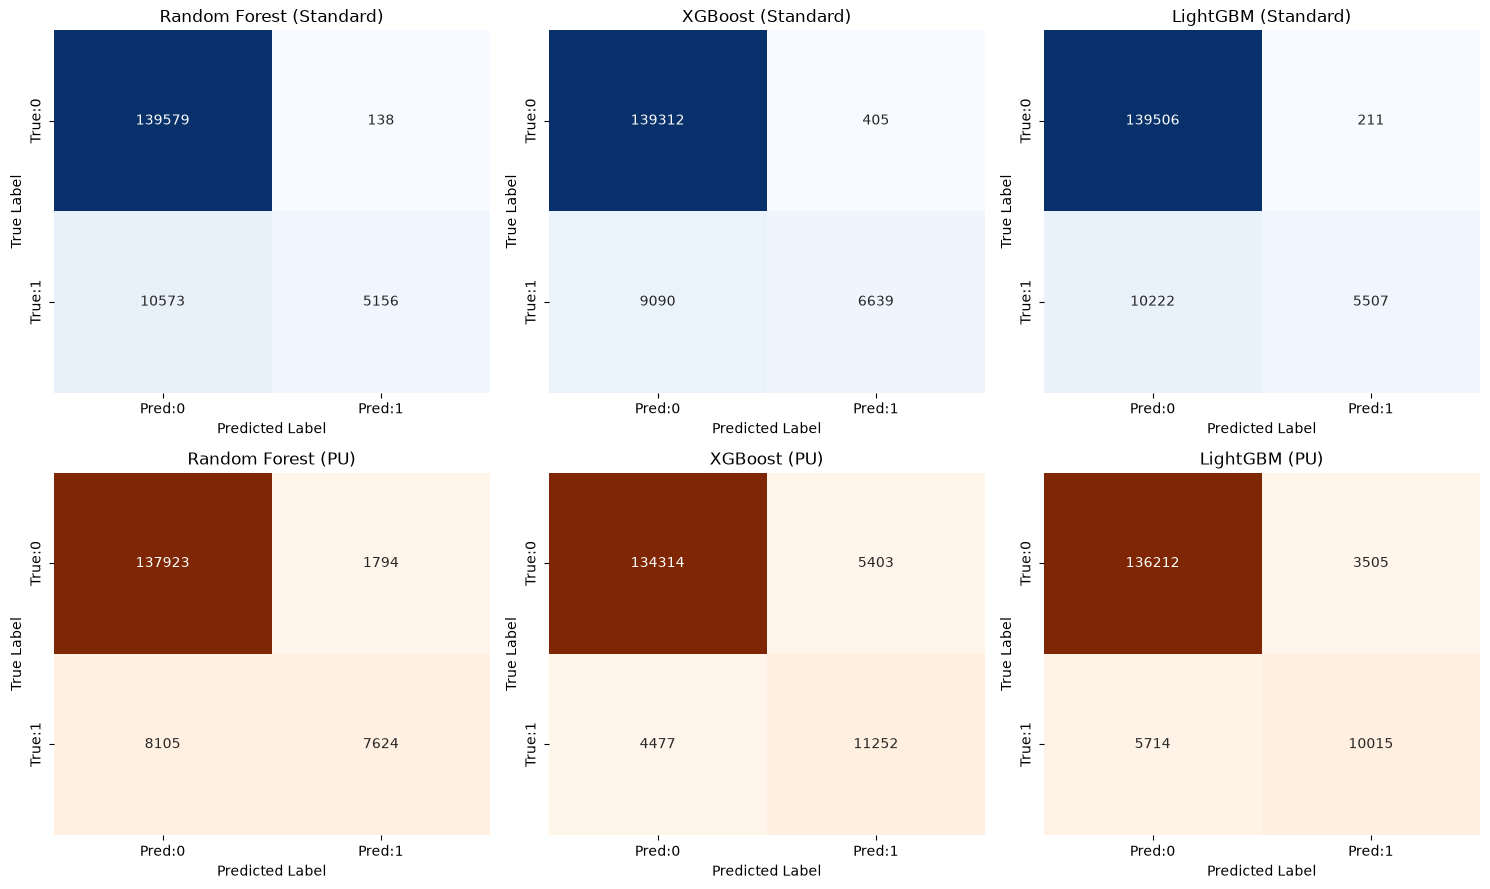

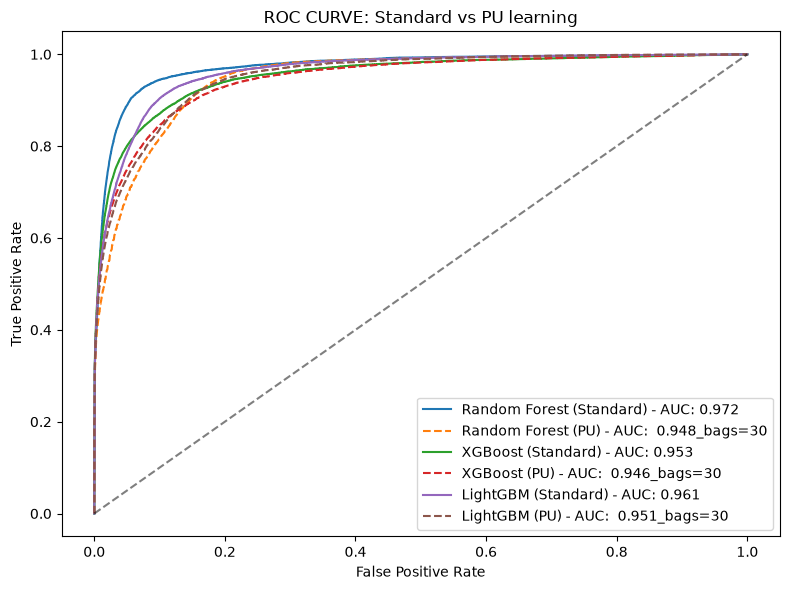

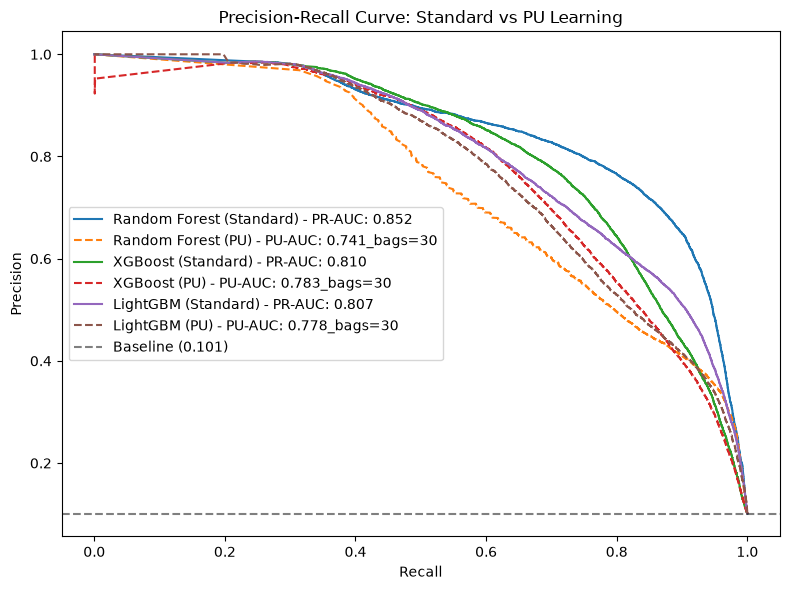

        Model        Type  Threshold  ROC-AUC  PR-AUC  Precision  Recall  F1-Score
Random Forest    Standard        0.8   0.9720  0.8516     0.9739  0.3278    0.4905
Random Forest PU Learning        0.8   0.9477  0.7409     0.8095  0.4847    0.6064
      XGBoost    Standard        0.8   0.9532  0.8101     0.9425  0.4221    0.5831
      XGBoost PU Learning        0.8   0.9463  0.7827     0.6756  0.7154    0.6949
     LightGBM    Standard        0.8   0.9612  0.8065     0.9631  0.3501    0.5135
     LightGBM PU Learning        0.8   0.9510  0.7784     0.7408  0.6367    0.6848


In [16]:
import  xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, average_precision_score, precision_recall_curve
from sklearn.base import clone
#=================

base_models = {
    "Random Forest":RandomForestClassifier(max_depth= 20, n_estimators=100, random_state=42),
    "XGBoost":xgb.XGBClassifier(learning_rate=0.1, max_depth=6, n_estimators=300,random_state=42),
    "LightGBM":lgb.LGBMClassifier( learning_rate= 0.05, max_depth= 10,  n_estimators= 200, random_state = 42)
} 
threshold = 0.8
results =[]
fig_cm, axes_cm = plt.subplots(2, 3, figsize=(15, 9))
fig_roc, ax_roc = plt.subplots(figsize=(8,6))
fig_prc, ax_prc = plt.subplots(figsize=(8,6)) # 計算 PR-AUC / AP


for idx, (name, base_clf) in enumerate(base_models.items()):
    std_clf = clone(base_clf)
    std_clf.fit(X_train_final, y_train)

    y_prob_std= std_clf.predict_proba(X_test_final)[:, 1]
    y_pred_std = (y_prob_std >= threshold).astype(int)

    auc_std = roc_auc_score(y_test, y_prob_std)
    pr_auc_std = average_precision_score(y_test, y_prob_std)

    prec_std, rec_std, _ = precision_recall_curve(y_test, y_prob_std)
    ax_prc.plot(rec_std, prec_std, label=f'{name} (Standard) - PR-AUC: {pr_auc_std:.3f}')
    

    results.append({
        "Model":name, "Type":"Standard", "Threshold":threshold,
        "ROC-AUC": round(auc_std, 4),
        "PR-AUC": round(pr_auc_std, 4),
        "Precision": round(precision_score(y_test, y_pred_std, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred_std, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, y_pred_std, zero_division=0), 4)
    })

    fpr_std, tpr_std, _ = roc_curve(y_test, y_prob_std)
    ax_roc.plot(fpr_std, tpr_std, label=f"{name} (Standard) - AUC: {auc_std:.3f}")

    cm = confusion_matrix(y_test, y_pred_std)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[0, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])

    axes_cm[0, idx].set_title(f"{name} (Standard)")
    axes_cm[0, idx].set_xlabel(f"Predicted Label")
    axes_cm[0, idx].set_ylabel(f"True Label")

    #============= Pu model
    n_bags= 30
    pu_clf= bagging_rf(n_bags,clone(base_clf), X_train_final, y_train)

    y_prob_pu =  pu_clf.predict_proba(X_test_final)[:, 1]
    y_pred_pu = (y_prob_pu >= threshold).astype(int)

    auc_pu = roc_auc_score(y_test, y_prob_pu)
    pr_auc_pu = average_precision_score(y_test, y_prob_pu)
    
    results.append({
        "Model": name, "Type": "PU Learning", "Threshold":threshold,
        "ROC-AUC": round(auc_pu, 4),
        "PR-AUC":round (pr_auc_pu, 4),
        "Precision": round(precision_score(y_test, y_pred_pu, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred_pu, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, y_pred_pu, zero_division=0 ), 4)
    })

    fpr_pu, tpr_pu, _ = roc_curve(y_test, y_prob_pu)
    ax_roc.plot(fpr_pu, tpr_pu, linestyle='--', label=f'{name} (PU) - AUC: {auc_pu: .3f}_bags={n_bags}')

    prec_pu, rec_pu, _ = precision_recall_curve(y_test, y_prob_pu)
    ax_prc.plot(rec_pu, prec_pu, linestyle='--', label=f'{name} (PU) - PU-AUC:{pr_auc_pu: .3f}_bags={n_bags}')

    cm = confusion_matrix(y_test, y_pred_pu)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes_cm[1, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])
    axes_cm[1, idx].set_title(f"{name} (PU)")
    axes_cm[1, idx].set_xlabel("Predicted Label")
    axes_cm[1, idx].set_ylabel("True Label")

ax_roc.plot([0, 1], [0,1], 'k--', alpha=0.5)
ax_roc.set_title("ROC CURVE: Standard vs PU learning")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend()

fig_roc.tight_layout()
fig_roc.savefig("img/PU_ROC_Comparison_30bags_final.png")



baseline_pr = np.sum(y_test == 1) / len(y_test)
ax_prc.axhline(y=baseline_pr, color='k', linestyle='--', alpha=0.5, label=f'Baseline ({baseline_pr:.3f})')
ax_prc.set_title("Precision-Recall Curve: Standard vs PU Learning")
ax_prc.set_xlabel("Recall")
ax_prc.set_ylabel("Precision")
ax_prc.legend()
fig_prc.tight_layout()
fig_prc.savefig("img/PU_PRC_Comparison_30bags_final.png")


fig_cm.tight_layout()
fig_cm.savefig("img/PU_Confusion_Matrix_Comparison_30bags_final.png")


plt.show()


df_metrics = pd.DataFrame(results)
print(df_metrics.to_string(index=False))
df_metrics.to_csv("img/PU_vs_Standard_Metrics_30bags_final.csv", index=False)
#===========

=====> top 30 feature is enough 

what if we use the features that selected from rf model?

In [6]:
feature_ml = ['level_area_ratio',
 'CH4_ht_to_last_std_ratio',
 'CH4_area_mad_3h',
 'CH4_ht_roll_std_1h',
 'CH4_w_roll_std_3h_CH4_w_roll_mean_3h_ratio',
 'CH4_ht',
 'CH4_skew',
 'CH4_area_to_last_std_ratio',
 'CH4_ht_roll_mean_1h',
 'CH4_area_roll_std_1h',
 'CH4_ht_pflow_ratio',
 'CH4_ht_mad_3h',
 'CH4_w_residual_3h',
 'CH4_w_residual_1h',
 'CH4_w_diff_1',
 'CH4_rt_to_last_std_ratio',
 'CH4_w_roll_std_1h',
 'CH4_area_pflow_ratio',
 'CH4_w_robust_residual_1h',
 'CH4_ht_roll_median_1h',
 'CH4_rt_to_last_air_ratio',
 'last_std_CH4_ht',
 'CH4_w_robust_residual_6h',
 'CH4_w_roll_mean_1h',
 'CH4_w_residual_6h',
 'CH4_w_roll_median_1h',
 'CH4_area_roll_mean_1h',
 'CH4_ht_roll_std_3h_CH4_ht_roll_mean_3h_ratio',
 'CH4_w_roll_std_3h',
 'CH4_rt_roll_mean_1h',]

In [7]:
X_train_final  = X_train_final [feature_ml]
X_test_final  = X_test_final [feature_ml]

Number of Bag: 5
Positive: 21442
Unlabeled: 600338

 PU training data, Bag 1/5 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 2/5 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 3/5 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 4/5 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 5/5 Positive = 21442, Unlabeled = 21442
Number of Bag: 10
Positive: 21442
Unlabeled: 600338

 PU training data, Bag 1/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 2/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 3/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 4/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 5/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 6/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 7/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 8/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 9/10 Positive = 21442, Unlabeled 

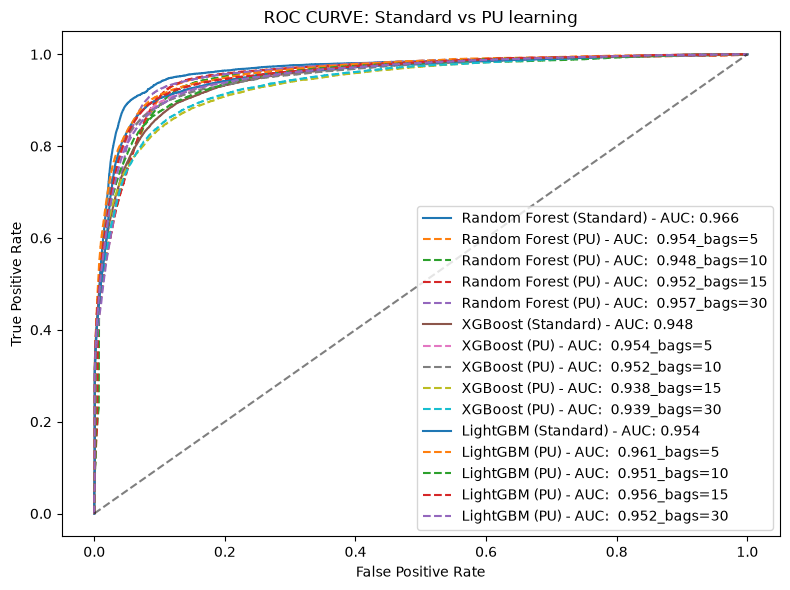

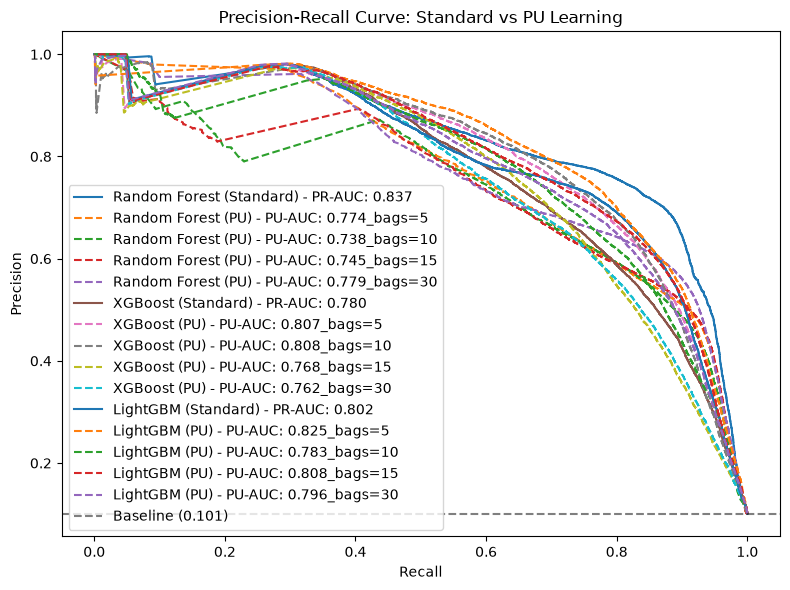

        Model        Type  Threshold  Bag  ROC-AUC  PR-AUC  Precision  Recall  F1-Score
Random Forest    Standard       0.50    0   0.9662  0.8373     0.8958  0.4549    0.6034
Random Forest    Standard       0.51    0   0.9662  0.8373     0.8991  0.4483    0.5983
Random Forest    Standard       0.52    0   0.9662  0.8373     0.9018  0.4412    0.5925
Random Forest    Standard       0.53    0   0.9662  0.8373     0.9039  0.4342    0.5866
Random Forest    Standard       0.54    0   0.9662  0.8373     0.9079  0.4293    0.5829
Random Forest    Standard       0.55    0   0.9662  0.8373     0.9118  0.4233    0.5782
Random Forest    Standard       0.56    0   0.9662  0.8373     0.9143  0.4179    0.5736
Random Forest    Standard       0.57    0   0.9662  0.8373     0.9177  0.4095    0.5663
Random Forest    Standard       0.58    0   0.9662  0.8373     0.9215  0.4047    0.5624
Random Forest    Standard       0.59    0   0.9662  0.8373     0.9244  0.3993    0.5577
Random Forest    Standard       

In [10]:
import  xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, average_precision_score, precision_recall_curve
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.base import clone
#=================
n_bags=0

base_models = {
    "Random Forest":RandomForestClassifier(max_depth= 20, n_estimators=100, random_state=42),
    "XGBoost":xgb.XGBClassifier(learning_rate=0.1, max_depth=6, n_estimators=300,random_state=42),
    "LightGBM":lgb.LGBMClassifier( learning_rate= 0.05, max_depth= 10,  n_estimators= 200, random_state = 42)
} 

threshold = 0.80
results =[]
#fig_cm, axes_cm = plt.subplots(2, 3, figsize=(15, 9))
fig_roc, ax_roc = plt.subplots(figsize=(8,6))
fig_prc, ax_prc = plt.subplots(figsize=(8,6)) # calculate PR-AUC / AP
best_fitted_models = {}
best_params_dict = {}
best_score_dict = {}
threshold_list= np.arange(0.5, 0.951, 0.01)
for idx, (name, base_clf) in enumerate(base_models.items()):

    best_std_clf = clone(base_clf)
   # best_std_clf.set_params(**best_params)
    best_std_clf.fit(X_train_final, y_train)

    best_fitted_models[name] = best_std_clf
    y_prob_std= best_std_clf.predict_proba(X_test_final)[:, 1]

    for threshold in threshold_list:
        y_pred_std = (y_prob_std >= threshold).astype(int)

        auc_std = roc_auc_score(y_test, y_prob_std)
        pr_auc_std = average_precision_score(y_test, y_prob_std)


        results.append({
            "Model":name, "Type":"Standard", "Threshold":threshold,"Bag":n_bags,
            "ROC-AUC": round(auc_std, 4),
            "PR-AUC": round(pr_auc_std, 4),
            "Precision": round(precision_score(y_test, y_pred_std, zero_division=0), 4),
            "Recall": round(recall_score(y_test, y_pred_std, zero_division=0), 4),
            "F1-Score": round(f1_score(y_test, y_pred_std, zero_division=0), 4)
        })
    prec_std, rec_std, _ = precision_recall_curve(y_test, y_prob_std)
    ax_prc.plot(rec_std, prec_std, label=f'{name} (Standard) - PR-AUC: {pr_auc_std:.3f}')

    fpr_std, tpr_std, _ = roc_curve(y_test, y_prob_std)
    ax_roc.plot(fpr_std, tpr_std, label=f"{name} (Standard) - AUC: {auc_std:.3f}")

        #cm = confusion_matrix(y_test, y_pred_std)
        #sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[0, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])

        #axes_cm[0, idx].set_title(f"{name} (Standard)")
        #axes_cm[0, idx].set_xlabel(f"Predicted Label")
        #axes_cm[0, idx].set_ylabel(f"True Label")

    #============= Pu model
    bag_list = [5, 10, 15, 30]
    for n_bags in bag_list:
        pu_clf= bagging_rf(n_bags,clone(best_std_clf), X_train_final, y_train)
        y_prob_pu =  pu_clf.predict_proba(X_test_final)[:, 1]
        for threshold in threshold_list:
            y_pred_pu = (y_prob_pu >= threshold).astype(int)

            auc_pu = roc_auc_score(y_test, y_prob_pu)
            pr_auc_pu = average_precision_score(y_test, y_prob_pu)
            
            results.append({
                "Model": name, "Type": "PU Learning", "Threshold":threshold,"Bag":n_bags,
                "ROC-AUC": round(auc_pu, 4),
                "PR-AUC":round (pr_auc_pu, 4),
                "Precision": round(precision_score(y_test, y_pred_pu, zero_division=0), 4),
                "Recall": round(recall_score(y_test, y_pred_pu, zero_division=0), 4),
                "F1-Score": round(f1_score(y_test, y_pred_pu, zero_division=0 ), 4)
            })

        fpr_pu, tpr_pu, _ = roc_curve(y_test, y_prob_pu)
        ax_roc.plot(fpr_pu, tpr_pu, linestyle='--', label=f'{name} (PU) - AUC: {auc_pu: .3f}_bags={n_bags}')

        prec_pu, rec_pu, _ = precision_recall_curve(y_test, y_prob_pu)
        ax_prc.plot(rec_pu, prec_pu, linestyle='--', label=f'{name} (PU) - PU-AUC:{pr_auc_pu: .3f}_bags={n_bags}')

    #cm = confusion_matrix(y_test, y_pred_pu)
    #sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes_cm[1, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])
    #xes_cm[1, idx].set_title(f"{name} (PU)")
    #axes_cm[1, idx].set_xlabel("Predicted Label")
    #axes_cm[1, idx].set_ylabel("True Label")

ax_roc.plot([0, 1], [0,1], 'k--', alpha=0.5)
ax_roc.set_title("ROC CURVE: Standard vs PU learning")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend()

fig_roc.tight_layout()
fig_roc.savefig("img/PU_ROC_Comparison_lightgb_bag_compar_rffeature.png")



baseline_pr = np.sum(y_test == 1) / len(y_test)
ax_prc.axhline(y=baseline_pr, color='k', linestyle='--', alpha=0.5, label=f'Baseline ({baseline_pr:.3f})')
ax_prc.set_title("Precision-Recall Curve: Standard vs PU Learning")
ax_prc.set_xlabel("Recall")
ax_prc.set_ylabel("Precision")
ax_prc.legend()
fig_prc.tight_layout()
fig_prc.savefig("img/PU_PRC_Comparison_lightgbm_bag_compar_rffeature.png")


#fig_cm.tight_layout()
#fig_cm.savefig("img/PU_Confusion_Matrix_Comparison_XGBOOST_bag_compar.png")


plt.show()


df_metrics = pd.DataFrame(results)
print(df_metrics.to_string(index=False))
df_metrics.to_csv("img/PU_vs_Standard_Metrics_lightgb_bag_compar_rffeature.csv", index=False)
#===========Rf model 

==========


oops this one is not right, it's default model

Number of Bag: 5
Positive: 21442
Unlabeled: 600338

 PU training data, Bag 1/5 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 2/5 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 3/5 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 4/5 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 5/5 Positive = 21442, Unlabeled = 21442
Number of Bag: 10
Positive: 21442
Unlabeled: 600338

 PU training data, Bag 1/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 2/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 3/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 4/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 5/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 6/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 7/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 8/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 9/10 Positive = 21442, Unlabeled 

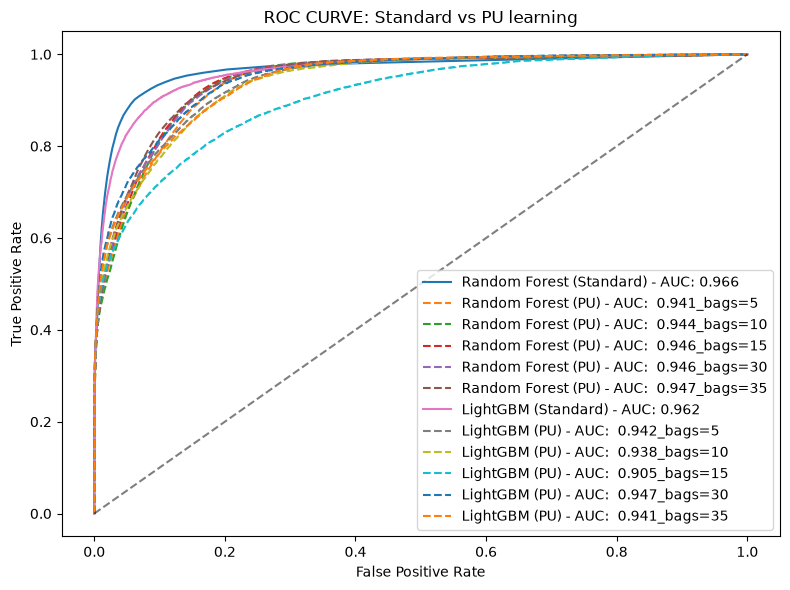

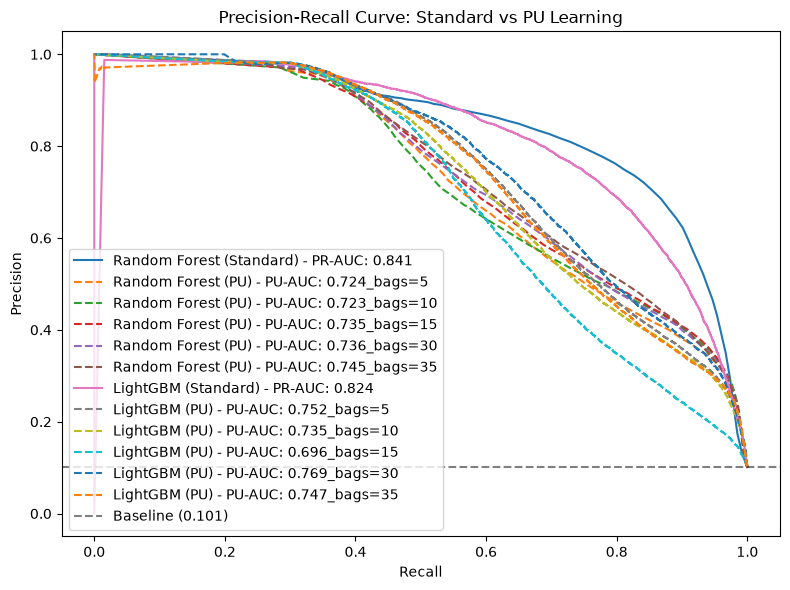

        Model        Type  Threshold  Bag  ROC-AUC  PR-AUC  Precision  Recall  F1-Score
Random Forest    Standard       0.50    0   0.9661  0.8413     0.9115  0.4359    0.5897
Random Forest    Standard       0.51    0   0.9661  0.8413     0.9136  0.4293    0.5841
Random Forest    Standard       0.52    0   0.9661  0.8413     0.9169  0.4235    0.5794
Random Forest    Standard       0.53    0   0.9661  0.8413     0.9195  0.4181    0.5749
Random Forest    Standard       0.54    0   0.9661  0.8413     0.9204  0.4124    0.5696
Random Forest    Standard       0.55    0   0.9661  0.8413     0.9236  0.4094    0.5673
Random Forest    Standard       0.56    0   0.9661  0.8413     0.9247  0.4050    0.5633
Random Forest    Standard       0.57    0   0.9661  0.8413     0.9298  0.3981    0.5575
Random Forest    Standard       0.58    0   0.9661  0.8413     0.9321  0.3951    0.5550
Random Forest    Standard       0.59    0   0.9661  0.8413     0.9344  0.3928    0.5531
Random Forest    Standard       

In [ ]:
import  xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, average_precision_score, precision_recall_curve
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.base import clone
#=================
n_bags=0
param_grids = {
    "Random Forest":{
        'n_estimators':[100],
        'max_depth': [10, 20],
        #'min_samples_split':[2, 5],
        #'class_weight':['balanced']
        },
    "XGBoost":{
        'n_estimators':[150, 200, 300],
        'max_depth':[4, 5, 6],
        'learning_rate':[0.1]
       # 'subample':[0.8],
        #'colsample_bytree':[0.8]
        },
    "LightGBM":{
        'learning_rate': 0.05, 
        'max_depth': 10, 
        'n_estimators': 200
        #'verbose':[-1]
    }
}
base_models = {
    "Random Forest":RandomForestClassifier(random_state=42),
    #"XGBoost":xgb.XGBClassifier(random_state=42),
    "LightGBM":lgb.LGBMClassifier(random_state = 42)
} 

threshold = 0.85
results =[]
#fig_cm, axes_cm = plt.subplots(2, 3, figsize=(15, 9))
fig_roc, ax_roc = plt.subplots(figsize=(8,6))
fig_prc, ax_prc = plt.subplots(figsize=(8,6)) # calculate PR-AUC / AP
best_fitted_models = {}
best_params_dict = {}
best_score_dict = {}
threshold_list= np.arange(0.5, 0.951, 0.01)
for idx, (name, base_clf) in enumerate(base_models.items()):


   # base_clf.fit(X_sub, y_sub)

    #best_params= grid_search.best_params_
    #best_params_dict[name] = grid_search.best_params_
    #best_score_dict[name] = grid_search.best_score_
    
    #print(f"Best parameter combination: {best_params}")
    best_std_clf = clone(base_clf)
   # best_std_clf.set_params(**best_params)
    best_std_clf.fit(X_train_final, y_train)

    best_fitted_models[name] = best_std_clf
    y_prob_std= best_std_clf.predict_proba(X_test_final)[:, 1]

    for threshold in threshold_list:
        y_pred_std = (y_prob_std >= threshold).astype(int)

        auc_std = roc_auc_score(y_test, y_prob_std)
        pr_auc_std = average_precision_score(y_test, y_prob_std)


        

        results.append({
            "Model":name, "Type":"Standard", "Threshold":threshold,"Bag":n_bags,
            "ROC-AUC": round(auc_std, 4),
            "PR-AUC": round(pr_auc_std, 4),
            "Precision": round(precision_score(y_test, y_pred_std, zero_division=0), 4),
            "Recall": round(recall_score(y_test, y_pred_std, zero_division=0), 4),
            "F1-Score": round(f1_score(y_test, y_pred_std, zero_division=0), 4)
        })
    prec_std, rec_std, _ = precision_recall_curve(y_test, y_prob_std)
    ax_prc.plot(rec_std, prec_std, label=f'{name} (Standard) - PR-AUC: {pr_auc_std:.3f}')

    fpr_std, tpr_std, _ = roc_curve(y_test, y_prob_std)
    ax_roc.plot(fpr_std, tpr_std, label=f"{name} (Standard) - AUC: {auc_std:.3f}")

        #cm = confusion_matrix(y_test, y_pred_std)
        #sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[0, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])

        #axes_cm[0, idx].set_title(f"{name} (Standard)")
        #axes_cm[0, idx].set_xlabel(f"Predicted Label")
        #axes_cm[0, idx].set_ylabel(f"True Label")

    #============= Pu model
    bag_list = [5, 10, 15, 30, 35]
    for n_bags in bag_list:
        pu_clf= bagging_rf(n_bags,clone(best_std_clf), X_train_final, y_train)
        y_prob_pu =  pu_clf.predict_proba(X_test_final)[:, 1]
        for threshold in threshold_list:
            y_pred_pu = (y_prob_pu >= threshold).astype(int)

            auc_pu = roc_auc_score(y_test, y_prob_pu)
            pr_auc_pu = average_precision_score(y_test, y_prob_pu)
            
            results.append({
                "Model": name, "Type": "PU Learning", "Threshold":threshold,"Bag":n_bags,
                "ROC-AUC": round(auc_pu, 4),
                "PR-AUC":round (pr_auc_pu, 4),
                "Precision": round(precision_score(y_test, y_pred_pu, zero_division=0), 4),
                "Recall": round(recall_score(y_test, y_pred_pu, zero_division=0), 4),
                "F1-Score": round(f1_score(y_test, y_pred_pu, zero_division=0 ), 4)
            })

        fpr_pu, tpr_pu, _ = roc_curve(y_test, y_prob_pu)
        ax_roc.plot(fpr_pu, tpr_pu, linestyle='--', label=f'{name} (PU) - AUC: {auc_pu: .3f}_bags={n_bags}')

        prec_pu, rec_pu, _ = precision_recall_curve(y_test, y_prob_pu)
        ax_prc.plot(rec_pu, prec_pu, linestyle='--', label=f'{name} (PU) - PU-AUC:{pr_auc_pu: .3f}_bags={n_bags}')

    #cm = confusion_matrix(y_test, y_pred_pu)
    #sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes_cm[1, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])
    #xes_cm[1, idx].set_title(f"{name} (PU)")
    #axes_cm[1, idx].set_xlabel("Predicted Label")
    #axes_cm[1, idx].set_ylabel("True Label")

ax_roc.plot([0, 1], [0,1], 'k--', alpha=0.5)
ax_roc.set_title("ROC CURVE: Standard vs PU learning")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend()

fig_roc.tight_layout()
fig_roc.savefig("img/PU_ROC_Comparison_lightgb_bag_compar.png")



baseline_pr = np.sum(y_test == 1) / len(y_test)
ax_prc.axhline(y=baseline_pr, color='k', linestyle='--', alpha=0.5, label=f'Baseline ({baseline_pr:.3f})')
ax_prc.set_title("Precision-Recall Curve: Standard vs PU Learning")
ax_prc.set_xlabel("Recall")
ax_prc.set_ylabel("Precision")
ax_prc.legend()
fig_prc.tight_layout()
fig_prc.savefig("img/PU_PRC_Comparison_lightgbm_bag_compar.png")


#fig_cm.tight_layout()
#fig_cm.savefig("img/PU_Confusion_Matrix_Comparison_XGBOOST_bag_compar.png")


plt.show()


df_metrics = pd.DataFrame(results)
print(df_metrics.to_string(index=False))
df_metrics.to_csv("img/PU_vs_Standard_Metrics_lightgb_bag_compar.csv", index=False)
#===========Rf model 

### again, with best parameter, three model comparison
best para:
rf: 'max_depth': 20, 'n_estimators': 100
xgb:'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300
lightgbn:'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 200



In [ ]:
import  xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, average_precision_score, precision_recall_curve
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.base import clone
#=================
n_bags=0
param_grids = {
    "Random Forest":{
        'n_estimators':[100],
        'max_depth': [10, 20],
        #'min_samples_split':[2, 5],
        #'class_weight':['balanced']
        },
    "XGBoost":{
        'n_estimators':[150, 200, 300],
        'max_depth':[4, 5, 6],
        'learning_rate':[0.1]
       # 'subample':[0.8],
        #'colsample_bytree':[0.8]
        },
    "LightGBM":{
        'learning_rate': 0.05, 
        'max_depth': 10, 
        'n_estimators': 200
        #'verbose':[-1]
    }
}
base_models = {
    "Random Forest":RandomForestClassifier(random_state=42),
    #"XGBoost":xgb.XGBClassifier(random_state=42),
    "LightGBM":lgb.LGBMClassifier(random_state = 42)
} 

threshold = 0.85
results =[]
#fig_cm, axes_cm = plt.subplots(2, 3, figsize=(15, 9))
fig_roc, ax_roc = plt.subplots(figsize=(8,6))
fig_prc, ax_prc = plt.subplots(figsize=(8,6)) # calculate PR-AUC / AP
best_fitted_models = {}
best_params_dict = {}
best_score_dict = {}
threshold_list= np.arange(0.5, 0.951, 0.01)
for idx, (name, base_clf) in enumerate(base_models.items()):


   # base_clf.fit(X_sub, y_sub)

    #best_params= grid_search.best_params_
    #best_params_dict[name] = grid_search.best_params_
    #best_score_dict[name] = grid_search.best_score_
    
    #print(f"Best parameter combination: {best_params}")
    best_std_clf = clone(base_clf)
   # best_std_clf.set_params(**best_params)
    best_std_clf.fit(X_train_final, y_train)

    best_fitted_models[name] = best_std_clf
    y_prob_std= best_std_clf.predict_proba(X_test_final)[:, 1]

    for threshold in threshold_list:
        y_pred_std = (y_prob_std >= threshold).astype(int)

        auc_std = roc_auc_score(y_test, y_prob_std)
        pr_auc_std = average_precision_score(y_test, y_prob_std)


        

        results.append({
            "Model":name, "Type":"Standard", "Threshold":threshold,"Bag":n_bags,
            "ROC-AUC": round(auc_std, 4),
            "PR-AUC": round(pr_auc_std, 4),
            "Precision": round(precision_score(y_test, y_pred_std, zero_division=0), 4),
            "Recall": round(recall_score(y_test, y_pred_std, zero_division=0), 4),
            "F1-Score": round(f1_score(y_test, y_pred_std, zero_division=0), 4)
        })
    prec_std, rec_std, _ = precision_recall_curve(y_test, y_prob_std)
    ax_prc.plot(rec_std, prec_std, label=f'{name} (Standard) - PR-AUC: {pr_auc_std:.3f}')

    fpr_std, tpr_std, _ = roc_curve(y_test, y_prob_std)
    ax_roc.plot(fpr_std, tpr_std, label=f"{name} (Standard) - AUC: {auc_std:.3f}")

        #cm = confusion_matrix(y_test, y_pred_std)
        #sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[0, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])

        #axes_cm[0, idx].set_title(f"{name} (Standard)")
        #axes_cm[0, idx].set_xlabel(f"Predicted Label")
        #axes_cm[0, idx].set_ylabel(f"True Label")

    #============= Pu model
    bag_list = [5, 10, 15, 30, 35]
    for n_bags in bag_list:
        pu_clf= bagging_rf(n_bags,clone(best_std_clf), X_train_final, y_train)
        y_prob_pu =  pu_clf.predict_proba(X_test_final)[:, 1]
        for threshold in threshold_list:
            y_pred_pu = (y_prob_pu >= threshold).astype(int)

            auc_pu = roc_auc_score(y_test, y_prob_pu)
            pr_auc_pu = average_precision_score(y_test, y_prob_pu)
            
            results.append({
                "Model": name, "Type": "PU Learning", "Threshold":threshold,"Bag":n_bags,
                "ROC-AUC": round(auc_pu, 4),
                "PR-AUC":round (pr_auc_pu, 4),
                "Precision": round(precision_score(y_test, y_pred_pu, zero_division=0), 4),
                "Recall": round(recall_score(y_test, y_pred_pu, zero_division=0), 4),
                "F1-Score": round(f1_score(y_test, y_pred_pu, zero_division=0 ), 4)
            })

        fpr_pu, tpr_pu, _ = roc_curve(y_test, y_prob_pu)
        ax_roc.plot(fpr_pu, tpr_pu, linestyle='--', label=f'{name} (PU) - AUC: {auc_pu: .3f}_bags={n_bags}')

        prec_pu, rec_pu, _ = precision_recall_curve(y_test, y_prob_pu)
        ax_prc.plot(rec_pu, prec_pu, linestyle='--', label=f'{name} (PU) - PU-AUC:{pr_auc_pu: .3f}_bags={n_bags}')

    #cm = confusion_matrix(y_test, y_pred_pu)
    #sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes_cm[1, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])
    #xes_cm[1, idx].set_title(f"{name} (PU)")
    #axes_cm[1, idx].set_xlabel("Predicted Label")
    #axes_cm[1, idx].set_ylabel("True Label")

ax_roc.plot([0, 1], [0,1], 'k--', alpha=0.5)
ax_roc.set_title("ROC CURVE: Standard vs PU learning")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend()

fig_roc.tight_layout()
fig_roc.savefig("img/PU_ROC_Comparison_lightgb_bag_compar.png")



baseline_pr = np.sum(y_test == 1) / len(y_test)
ax_prc.axhline(y=baseline_pr, color='k', linestyle='--', alpha=0.5, label=f'Baseline ({baseline_pr:.3f})')
ax_prc.set_title("Precision-Recall Curve: Standard vs PU Learning")
ax_prc.set_xlabel("Recall")
ax_prc.set_ylabel("Precision")
ax_prc.legend()
fig_prc.tight_layout()
fig_prc.savefig("img/PU_PRC_Comparison_lightgbm_bag_compar.png")


#fig_cm.tight_layout()
#fig_cm.savefig("img/PU_Confusion_Matrix_Comparison_XGBOOST_bag_compar.png")


plt.show()


df_metrics = pd.DataFrame(results)
print(df_metrics.to_string(index=False))
df_metrics.to_csv("img/PU_vs_Standard_Metrics_lightgb_bag_compar.csv", index=False)
#===========Rf model 

### what if we put all features? 

In [ ]:
import  xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, average_precision_score, precision_recall_curve
from sklearn.base import clone
#=================
base_models = {
    "Random Forest":RandomForestClassifier(
    max_depth=20, n_estimators= 100,
    random_state=42
),
"XGBoost": xgb.XGBClassifier(
    learning_rate=0.1, max_depth=5, n_estimators= 200,
    random_state=42
),
"LightGBM":lgb.LGBMClassifier(
    random_state = 42,
)
} 
threshold = 0.8
results =[]
fig_cm, axes_cm = plt.subplots(2, 3, figsize=(15, 9))
fig_roc, ax_roc = plt.subplots(figsize=(8,6))
fig_prc, ax_prc = plt.subplots(figsize=(8,6)) # 計算 PR-AUC / AP


for idx, (name, base_clf) in enumerate(base_models.items()):
    std_clf = clone(base_clf)
    std_clf.fit(X_train_final, y_train)

    y_prob_std= std_clf.predict_proba(X_test_final)[:, 1]
    y_pred_std = (y_prob_std >= threshold).astype(int)

    auc_std = roc_auc_score(y_test, y_prob_std)
    pr_auc_std = average_precision_score(y_test, y_prob_std)

    prec_std, rec_std, _ = precision_recall_curve(y_test, y_prob_std)
    ax_prc.plot(rec_std, prec_std, label=f'{name} (Standard) - PR-AUC: {pr_auc_std:.3f}')
    

    results.append({
        "Model":name, "Type":"Standard", "Threshold":threshold,
        "ROC-AUC": round(auc_std, 4),
        "PR-AUC": round(pr_auc_std, 4),
        "Precision": round(precision_score(y_test, y_pred_std, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred_std, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, y_pred_std, zero_division=0), 4)
    })

    fpr_std, tpr_std, _ = roc_curve(y_test, y_prob_std)
    ax_roc.plot(fpr_std, tpr_std, label=f"{name} (Standard) - AUC: {auc_std:.3f}")

    cm = confusion_matrix(y_test, y_pred_std)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[0, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])

    axes_cm[0, idx].set_title(f"{name} (Standard)")
    axes_cm[0, idx].set_xlabel(f"Predicted Label")
    axes_cm[0, idx].set_ylabel(f"True Label")

    #============= Pu model
    n_bags= 30
    pu_clf= bagging_rf(n_bags,clone(base_clf), X_train_final, y_train)

    y_prob_pu =  pu_clf.predict_proba(X_test_final)[:, 1]
    y_pred_pu = (y_prob_pu >= threshold).astype(int)

    auc_pu = roc_auc_score(y_test, y_prob_pu)
    pr_auc_pu = average_precision_score(y_test, y_prob_pu)
    
    results.append({
        "Model": name, "Type": "PU Learning", "Threshold":threshold,
        "ROC-AUC": round(auc_pu, 4),
        "PR-AUC":round (pr_auc_pu, 4),
        "Precision": round(precision_score(y_test, y_pred_pu, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred_pu, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, y_pred_pu, zero_division=0 ), 4)
    })

    fpr_pu, tpr_pu, _ = roc_curve(y_test, y_prob_pu)
    ax_roc.plot(fpr_pu, tpr_pu, linestyle='--', label=f'{name} (PU) - AUC: {auc_pu: .3f}')

    prec_pu, rec_pu, _ = precision_recall_curve(y_test, y_prob_pu)
    ax_prc.plot(rec_pu, prec_pu, linestyle='--', label=f'{name} (PU) - PU-AUC:{pr_auc_pu: .3f}')

    cm = confusion_matrix(y_test, y_pred_pu)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes_cm[1, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])
    axes_cm[1, idx].set_title(f"{name} (PU)")
    axes_cm[1, idx].set_xlabel("Predicted Label")
    axes_cm[1, idx].set_ylabel("True Label")

ax_roc.plot([0, 1], [0,1], 'k--', alpha=0.5)
ax_roc.set_title("ROC CURVE: Standard vs PU learning")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend()

fig_roc.tight_layout()
fig_roc.savefig("img/PU_ROC_Comparison_best_param_30bags_v1.png")



baseline_pr = np.sum(y_test == 1) / len(y_test)
ax_prc.axhline(y=baseline_pr, color='k', linestyle='--', alpha=0.5, label=f'Baseline ({baseline_pr:.3f})')
ax_prc.set_title("Precision-Recall Curve: Standard vs PU Learning")
ax_prc.set_xlabel("Recall")
ax_prc.set_ylabel("Precision")
ax_prc.legend()
fig_prc.tight_layout()
fig_prc.savefig("img/PU_PRC_Comparison_best_param_30bags_v1.png")


fig_cm.tight_layout()
fig_cm.savefig("img/PU_Confusion_Matrix_Comparison_best_param_30bags_v1.png")


plt.show()


df_metrics = pd.DataFrame(results)
print(df_metrics.to_string(index=False))
df_metrics.to_csv("img/PU_vs_Standard_Metrics_best_param_30bags_v1.csv", index=False)
#===========

In [ ]:
import  xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, average_precision_score, precision_recall_curve
from sklearn.base import clone
#=================
base_models = {
    "Random Forest":RandomForestClassifier(
    random_state=42
),
"XGBoost": xgb.XGBClassifier(
    random_state=42
),
"LightGBM":lgb.LGBMClassifier(
    random_state = 42,
)
} 
threshold = 0.8
results =[]
fig_cm, axes_cm = plt.subplots(2, 3, figsize=(15, 9))
fig_roc, ax_roc = plt.subplots(figsize=(8,6))
fig_prc, ax_prc = plt.subplots(figsize=(8,6)) # 計算 PR-AUC / AP


for idx, (name, base_clf) in enumerate(base_models.items()):
    std_clf = clone(base_clf)
    std_clf.fit(X_train_final, y_train)

    y_prob_std= std_clf.predict_proba(X_test_final)[:, 1]
    y_pred_std = (y_prob_std >= threshold).astype(int)

    auc_std = roc_auc_score(y_test, y_prob_std)
    pr_auc_std = average_precision_score(y_test, y_prob_std)

    prec_std, rec_std, _ = precision_recall_curve(y_test, y_prob_std)
    ax_prc.plot(rec_std, prec_std, label=f'{name} (Standard) - PR-AUC: {pr_auc_std:.3f}')
    

    results.append({
        "Model":name, "Type":"Standard", "Threshold":threshold,
        "ROC-AUC": round(auc_std, 4),
        "PR-AUC": round(pr_auc_std, 4),
        "Precision": round(precision_score(y_test, y_pred_std, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred_std, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, y_pred_std, zero_division=0), 4)
    })

    fpr_std, tpr_std, _ = roc_curve(y_test, y_prob_std)
    ax_roc.plot(fpr_std, tpr_std, label=f"{name} (Standard) - AUC: {auc_std:.3f}")

    cm = confusion_matrix(y_test, y_pred_std)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[0, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])

    axes_cm[0, idx].set_title(f"{name} (Standard)")
    axes_cm[0, idx].set_xlabel(f"Predicted Label")
    axes_cm[0, idx].set_ylabel(f"True Label")

    #============= Pu model
    n_bags= 30
    pu_clf= bagging_rf(n_bags,clone(base_clf), X_train_final, y_train)

    y_prob_pu =  pu_clf.predict_proba(X_test_final)[:, 1]
    y_pred_pu = (y_prob_pu >= threshold).astype(int)

    auc_pu = roc_auc_score(y_test, y_prob_pu)
    pr_auc_pu = average_precision_score(y_test, y_prob_pu)
    
    results.append({
        "Model": name, "Type": "PU Learning", "Threshold":threshold,
        "ROC-AUC": round(auc_pu, 4),
        "PR-AUC":round (pr_auc_pu, 4),
        "Precision": round(precision_score(y_test, y_pred_pu, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred_pu, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, y_pred_pu, zero_division=0 ), 4)
    })

    fpr_pu, tpr_pu, _ = roc_curve(y_test, y_prob_pu)
    ax_roc.plot(fpr_pu, tpr_pu, linestyle='--', label=f'{name} (PU) - AUC: {auc_pu: .3f}')

    prec_pu, rec_pu, _ = precision_recall_curve(y_test, y_prob_pu)
    ax_prc.plot(rec_pu, prec_pu, linestyle='--', label=f'{name} (PU) - PU-AUC:{pr_auc_pu: .3f}')

    cm = confusion_matrix(y_test, y_pred_pu)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes_cm[1, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])
    axes_cm[1, idx].set_title(f"{name} (PU)")
    axes_cm[1, idx].set_xlabel("Predicted Label")
    axes_cm[1, idx].set_ylabel("True Label")

ax_roc.plot([0, 1], [0,1], 'k--', alpha=0.5)
ax_roc.set_title("ROC CURVE: Standard vs PU learning")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend()

fig_roc.tight_layout()
fig_roc.savefig("img/PU_ROC_Comparison.png")



baseline_pr = np.sum(y_test == 1) / len(y_test)
ax_prc.axhline(y=baseline_pr, color='k', linestyle='--', alpha=0.5, label=f'Baseline ({baseline_pr:.3f})')
ax_prc.set_title("Precision-Recall Curve: Standard vs PU Learning")
ax_prc.set_xlabel("Recall")
ax_prc.set_ylabel("Precision")
ax_prc.legend()
fig_prc.tight_layout()
fig_prc.savefig("img/PU_PRC_Comparison.png")


fig_cm.tight_layout()
fig_cm.savefig("img/PU_Confusion_Matrix_Comparison.png")


plt.show()


df_metrics = pd.DataFrame(results)
print(df_metrics.to_string(index=False))
df_metrics.to_csv("img/PU_vs_Standard_Metrics.csv", index=False)
#===========

In [14]:
ax_roc.plot([0, 1], [0,1], 'k--', alpha=0.5)
ax_roc.set_title("ROC CURVE: Standard vs PU learning")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend()

fig_roc.tight_layout()
fig_roc.savefig("img/PU_ROC_Comparison.png")



baseline_pr = np.sum(y_test == 1) / len(y_test)
ax_prc.axhline(y=baseline_pr, color='k', linestyle='--', alpha=0.5, label=f'Baseline ({baseline_pr:.3f})')
ax_prc.set_title("Precision-Recall Curve: Standard vs PU Learning")
ax_prc.set_xlabel("Recall")
ax_prc.set_ylabel("Precision")
ax_prc.legend()
fig_prc.tight_layout()
fig_prc.savefig("img/PU_PRC_Comparison.png")


fig_cm.tight_layout()
fig_cm.savefig("img/PU_Confusion_Matrix_Comparison.png")


plt.show()


df_metrics = pd.DataFrame(results)
print(df_metrics.to_string(index=False))
df_metrics.to_csv("img/PU_vs_Standard_Metrics.csv", index=False)
#===========

        Model        Type  Threshold  ROC-AUC  PR-AUC  Precision  Recall  F1-Score
Random Forest    Standard        0.8   0.9661  0.8413     0.9735  0.3265    0.4890
Random Forest PU Learning        0.8   0.9455  0.7364     0.8059  0.4880    0.6079
      XGBoost    Standard        0.8   0.9337  0.7600     0.9234  0.4414    0.5972
      XGBoost PU Learning        0.8   0.9214  0.7361     0.6684  0.6536    0.6609
     LightGBM    Standard        0.8   0.9622  0.8240     0.9503  0.3735    0.5363
     LightGBM PU Learning        0.8   0.9473  0.7692     0.7378  0.6314    0.6805


#============ threshold

In [26]:
import  xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, average_precision_score, precision_recall_curve
from sklearn.base import clone
#=================
base_models = {
    "Random Forest":RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=5,
    max_samples=0.8,
    n_jobs=-1,
    random_state=42
),
"XGBoost": xgb.XGBClassifier(
    n_estimators=100,
    learning_rate = 0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree = 0.8,
    tree_method='hist',
    n_jobs=-1,
    random_state=42
),
"LightGBM":lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate = 0.1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree = 0.8,
    n_jobs=-1,
    random_state = 42,

)
} 


fixed_threshold = 0.8
threshold_candi = np.linspace(0.01, 0.99, 99)
comparison_results = []
def get_best_threshold(y_true, y_prob):
    best_thresh = 0.5
    best_f1 = -1
    best_prec = 0
    best_rec = 0

    for thresh in threshold_candi:
        y_pred = (y_prob >= thresh).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh
            best_prec = precision_score(y_true, y_pred, zero_division=0)
            best_rec = recall_score(y_true, y_pred, zero_division=0)


    return best_thresh, best_prec, best_rec, best_f1


for idx, (name, base_clf) in enumerate(base_models.items()):
    std_clf = clone(base_clf)
    std_clf.fit(X_train_final, y_train_final)

    y_prob_std= std_clf.predict_proba(X_test_final)[:, 1]

    y_pred_std_fixed = (y_prob_std >= fixed_threshold).astype(int)
    f1_std_fixed = f1_score(y_test_final, y_pred_std_fixed, zero_division=0)
    prec_std_fixed = precision_score(y_test_final, y_pred_std_fixed, zero_division=0)
    rec_std_fixed = recall_score(y_test_final, y_pred_std_fixed, zero_division=0)

    best_thresh_std, prec_std_opt, rec_std_opt, f1_std_opt = get_best_threshold(y_test_final, y_prob_std)


    comparison_results.append({
        "Model":name, "Type":"Standard", 
        "Ori Threshold":threshold,
        "Ori F1": round(f1_std_fixed, 4),
        "Best Thresh": round(best_thresh_std, 2),
        "Opt Precision":round(prec_std_opt, 4),
        "Opt Precision": round(prec_std_opt, 4),
        "Opt Recall": round(rec_std_opt, 4),
        "Opt F1": round(f1_std_opt, 4),
        "F1 Gain": round(f1_std_opt-f1_std_fixed, 4),
    })

    #============= Pu model

    pu_clf = ElkanotoPuClassifier(
    estimator=clone(base_clf),
    hold_out_ratio=0.2
    )
    
    pu_clf.fit(X_train_final, y_train_final)

    y_prob_pu = pu_clf.predict_proba(X_test_final)[:, 1]

    y_pred_pu_fixed = (y_prob_pu >= fixed_threshold).astype(int)
    f1_pu_fixed = f1_score(y_test_final, y_pred_pu_fixed, zero_division=0)
    prec_pu_fixed = precision_score(y_test_final, y_pred_pu_fixed, zero_division=0)
    rec_pu_fized = recall_score(y_test_final, y_pred_pu_fixed, zero_division=0)


    best_thresh_pu, prec_pu_opt, rec_pu_opt, f1_pu_opt = get_best_threshold(y_test_final, y_prob_pu)

    comparison_results.append({
        "Model":name, "Type":"PU Learning", 
        "Ori Threshold":fixed_threshold,
        "Ori F1": round(f1_pu_fixed, 4),
        "Best Thresh": round(best_thresh_pu, 2),
        "Opt Precision":round(prec_pu_opt, 4),
        "Opt Precision": round(prec_pu_opt, 4),
        "Opt Recall": round(rec_pu_opt, 4),
        "Opt F1": round(f1_pu_opt, 4),
        "F1 Gain": round(f1_pu_opt-f1_pu_fixed, 4),
    })

df_metrics = pd.DataFrame(comparison_results)
print(df_metrics.to_string(index=False))
df_metrics.to_csv("image/PU_vs_Standard_Metrics.csv", index=False)

/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 21442, number of negative: 600338
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011333 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7461
[LightGBM] [Info] Number of data points in the train set: 621780, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034485 -> initscore=-3.332141
[LightGBM] [Info] Start training from score -3.332141
[LightGBM] [Info] Number of positive: 17072, number of negative: 480352
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.034013 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7449
[LightGBM] [Info] Number of data points in the train set: 497424, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034321 -> initscore=-3.33707

In [30]:
df_metrics

,Model,Type,Ori Threshold,Ori F1,Best Thresh,Opt Precision,Opt Recall,Opt F1,F1 Gain
0,Random Forest,Standard,0.8,0.5265,0.07,0.6491,0.8620,0.7406,0.2141
1,Random Forest,PU Learning,0.8,0.5873,0.12,0.6587,0.8364,0.7370,0.1497
2,XGBoost,Standard,0.8,0.5842,0.13,0.7443,0.7475,0.7459,0.1617
3,XGBoost,PU Learning,0.8,0.6227,0.11,0.7021,0.7760,0.7372,0.1145
4,LightGBM,Standard,0.8,0.6826,0.16,0.7199,0.8154,0.7646,0.0820
5,LightGBM,PU Learning,0.8,0.7232,0.23,0.7227,0.8003,0.7595,0.0363


import joblib
joblib.dump(pu_estimator, "pu_rf_model_0730v1.joblib")

import joblib
pu_estimator = joblib.load("pu_rf_model_0730v1.joblib")

In [28]:
base_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=5,
    max_samples=0.8,
    n_jobs=-1,
    random_state=42
)

pu_estimator = ElkanotoPuClassifier(
    estimator=base_rf,
    hold_out_ratio=0.2
)

pu_estimator.fit(X_train_final, y_train_final)

,estimator,RandomForestC...ndom_state=42)
,hold_out_ratio,0.2
,random_state,None
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"max_samples max_samples: int or float, default=NoneIf bootstrap is True, the number of samples to draw from Xto train each base estimator.- If None (default), then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples... versionadded:: 0.22.. versionchanged:: 1.9 Float `max_samples` is relative to `sample_weight.sum()` instead of `X.shape[0]` for weighted samples.",0.8
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100


/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


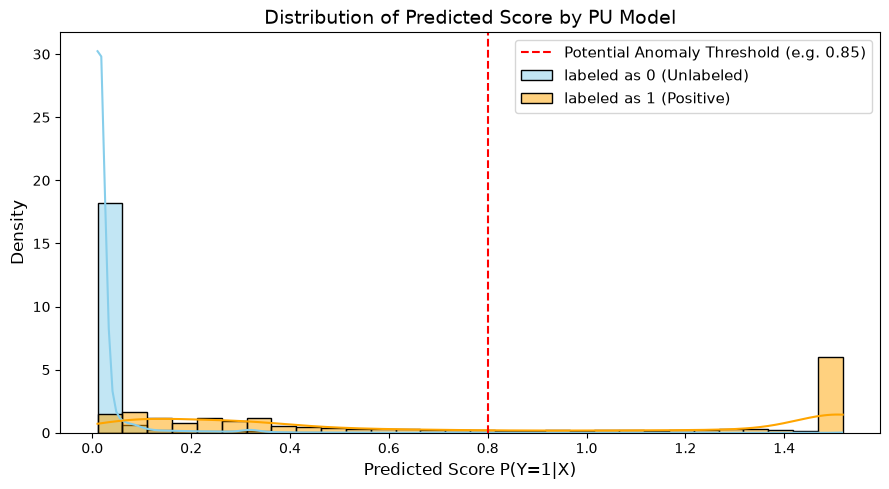

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
best_threshold = 0.8
y_probs = pu_estimator.predict_proba(X_test_final)[:,1]

probs_pos = y_probs[y_test_final == 1]
probs_unl = y_probs[y_test_final == 0]


plt.figure(figsize=(9,5))

sns.histplot(probs_unl, color='skyblue', label='labeled as 0 (Unlabeled)', kde=True, stat='density', bins=30, alpha=0.5)
sns.histplot(probs_pos, color='orange', label='labeled as 1 (Positive)', kde=True, stat='density', bins=30, alpha=0.5)

plt.axvline(x=0.8, color='red', linestyle='--', label='Potential Anomaly Threshold (e.g. 0.85)')

plt.title("Distribution of Predicted Score by PU Model", fontsize=14)
plt.xlabel("Predicted Score P(Y=1|X)", fontsize=12)
plt.ylabel("Density", fontsize=12)

plt.legend(fontsize=11)

plt.tight_layout()
plt.savefig("image/ PU_Probability_distribution.png")

plt.show()

#============================== 


In [13]:
threshold = 0.8

potential_anomaly_mask = (y_test_final.values==0) & (y_probs>=0.8)

potential_anomalies = X_test_final.loc[potential_anomaly_mask].copy()
potential_anomalies['pu_score'] = y_probs[potential_anomaly_mask]

potential_anomalies = potential_anomalies.sort_values(by='pu_score', ascending=False)
potential_anomalies.head(20)

,pflow,tmod,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,is_air,is_std,last_std_CH4_ht,last_air_CH4_ht,last_std_CH4_area,last_air_CH4_area,last_std_CH4_rt,last_air_CH4_rt,last_std_CH4_start_level,last_air_CH4_start_level,CH4_ht_to_last_std_ratio,CH4_ht_to_last_air_ratio,CH4_area_to_last_std_ratio,CH4_area_to_last_air_ratio,CH4_rt_to_last_std_ratio,CH4_rt_to_last_air_ratio,CH4_start_level_to_last_std_ratio,CH4_start_level_to_last_air_ratio,duration_rt_ratio,rt_position,baseline_slope,level_area_ratio,CH4_area_diff_1,CH4_area_diff_3,CH4_area_diff_6,CH4_area_diff_72,CH4_ht_diff_1,CH4_ht_diff_3,CH4_ht_diff_6,CH4_ht_diff_72,CH4_w_diff_1,CH4_w_diff_3,CH4_w_diff_6,CH4_w_diff_72,CH4_rt_diff_1,CH4_rt_diff_3,CH4_rt_diff_6,CH4_rt_diff_72,CH4_area_lag_1,CH4_area_lag_3,CH4_area_lag_6,CH4_area_lag_72,CH4_rt_lag_1,CH4_rt_lag_3,CH4_rt_lag_6,CH4_rt_lag_72,CH4_ht_lag_1,CH4_ht_lag_3,CH4_ht_lag_6,CH4_ht_lag_72,pflow_lag_1,pflow_lag_3,pflow_lag_6,pflow_lag_72,CH4_w_lag_1,CH4_w_lag_3,CH4_w_lag_6,CH4_w_lag_72,CH4_ht_CH4_ht_lag_72_diff_cross,CH4_area_CH4_area_lag_72_diff_cross,CH4_end_time_CH4_start_time_diff_cross,CH4_end_level_CH4_start_level_diff_cross,CH4_rt_pflow_diff_cross,CH4_w_roll_std_1h,CH4_w_roll_std_3h,CH4_w_roll_std_6h,CH4_w_roll_std_24h,CH4_w_roll_std_3D,CH4_w_roll_std_7D,CH4_ht_roll_std_1h,CH4_ht_roll_std_3h,CH4_ht_roll_std_6h,CH4_ht_roll_std_24h,CH4_ht_roll_std_3D,CH4_ht_roll_std_7D,CH4_area_roll_std_1h,CH4_area_roll_std_3h,CH4_area_roll_std_6h,CH4_area_roll_std_24h,CH4_area_roll_std_3D,CH4_area_roll_std_7D,CH4_end_time_CH4_start_time_diff_cross_roll_std_1h,CH4_end_time_CH4_start_time_diff_cross_roll_std_3h,CH4_end_time_CH4_start_time_diff_cross_roll_std_6h,CH4_end_time_CH4_start_time_diff_cross_roll_std_24h,CH4_end_time_CH4_start_time_diff_cross_roll_std_3D,CH4_end_time_CH4_start_time_diff_cross_roll_std_7D,CH4_rt_roll_mean_1h,CH4_rt_residual_1h,CH4_rt_roll_mean_3h,CH4_rt_residual_3h,CH4_rt_roll_mean_6h,CH4_rt_residual_6h,CH4_rt_roll_mean_24h,CH4_rt_residual_24h,CH4_rt_roll_mean_3D,CH4_rt_residual_3D,CH4_rt_roll_mean_7D,CH4_rt_residual_7D,CH4_w_roll_mean_1h,CH4_w_residual_1h,CH4_w_roll_mean_3h,CH4_w_residual_3h,CH4_w_roll_mean_6h,CH4_w_residual_6h,CH4_w_roll_mean_24h,CH4_w_residual_24h,CH4_w_roll_mean_3D,CH4_w_residual_3D,CH4_w_roll_mean_7D,CH4_w_residual_7D,CH4_ht_roll_mean_1h,CH4_ht_residual_1h,CH4_ht_roll_mean_3h,CH4_ht_residual_3h,CH4_ht_roll_mean_6h,CH4_ht_residual_6h,CH4_ht_roll_mean_24h,CH4_ht_residual_24h,CH4_ht_roll_mean_3D,CH4_ht_residual_3D,CH4_ht_roll_mean_7D,CH4_ht_residual_7D,CH4_area_roll_mean_1h,CH4_area_residual_1h,CH4_area_roll_mean_3h,CH4_area_residual_3h,CH4_area_roll_mean_6h,CH4_area_residual_6h,CH4_area_roll_mean_24h,CH4_area_residual_24h,CH4_area_roll_mean_3D,CH4_area_residual_3D,CH4_area_roll_mean_7D,CH4_area_residual_7D,CH4_rt_roll_median_1h,CH4_rt_roll_median_3h,CH4_rt_roll_median_6h,CH4_rt_roll_median_24h,CH4_rt_roll_median_3D,CH4_rt_roll_median_7D,CH4_w_roll_median_1h,CH4_w_roll_median_3h,CH4_w_roll_median_6h,CH4_w_roll_median_24h,CH4_w_roll_median_3D,CH4_w_roll_median_7D,CH4_ht_roll_median_1h,CH4_ht_roll_median_3h,CH4_ht_roll_median_6h,CH4_ht_roll_median_24h,CH4_ht_roll_median_3D,CH4_ht_roll_median_7D,CH4_area_roll_median_1h,CH4_area_roll_median_3h,CH4_area_roll_median_6h,CH4_area_roll_median_24h,CH4_area_roll_median_3D,CH4_area_roll_median_7D,pflow_roll_median_1h,pflow_roll_median_3h,pflow_roll_median_6h,pflow_roll_median_24h,pflow_roll_median_3D,pflow_roll_median_7D,CH4_area_lag_72_roll_median_1h,CH4_area_lag_72_roll_median_3h,CH4_area_lag_72_roll_median_6h,CH4_area_lag_72_roll_median_24h,CH4_area_lag_72_roll_median_3D,CH4_area_lag_72_roll_median_7D,CH4_ht_lag_72_roll_median_1h,CH4_ht_lag_72_roll_median_3h,CH4_ht_lag_72_roll_median_6h,CH4_ht_lag_72_roll_median_24h,CH4_ht_lag_72_roll_median_3D,CH4_ht_lag_72_roll_median_7D,CH4_rt_mad_1h,CH4_rt_mad_3h,CH4_rt_mad_6h,CH4_rt_mad_24h,CH4_rt_mad_3D,CH4_rt_mad_7D,CH4_w_mad_1h,CH4_w_mad_3h,CH4_w_mad_6h,CH4_w_mad_

In [14]:
len(potential_anomalies)

464

In [15]:
potential_anomalies.to_csv("pu_anomaly_0730.csv")

===============

/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


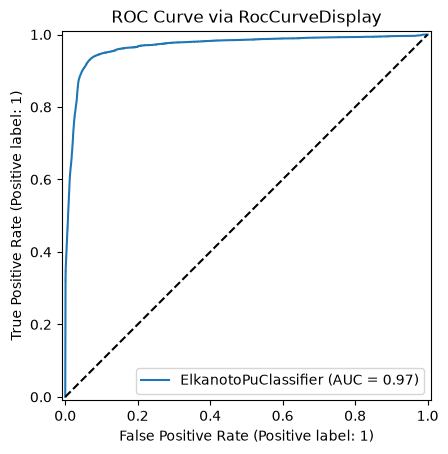

/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


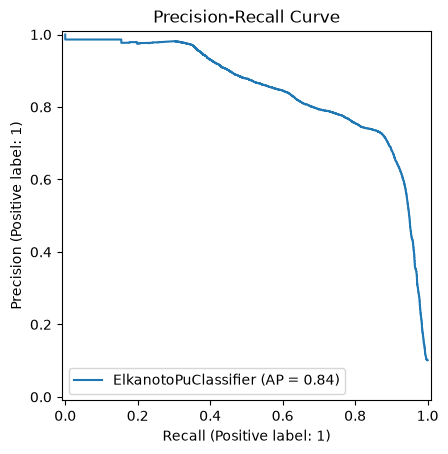

In [16]:

#=========== plotting
#======== ROC
RocCurveDisplay.from_estimator(pu_estimator, X_test_final, y_test_final)

plt.title("ROC Curve via RocCurveDisplay")
plt.plot([0, 1], [0,1], 'k--') 
plt.savefig("image/ROC_Curve.png")
#mlflow.log_artifact("image/ROC_Curve.png")
plt.show()    
plt.close()
# ======= PRC 
PrecisionRecallDisplay.from_estimator(pu_estimator, X_test_final, y_test_final)

plt.title("Precision-Recall Curve")
plt.savefig("image/PRC_Curve.png")
#mlflow.log_artifact("image/PRC_Curve.png")
plt.show()    
plt.close()

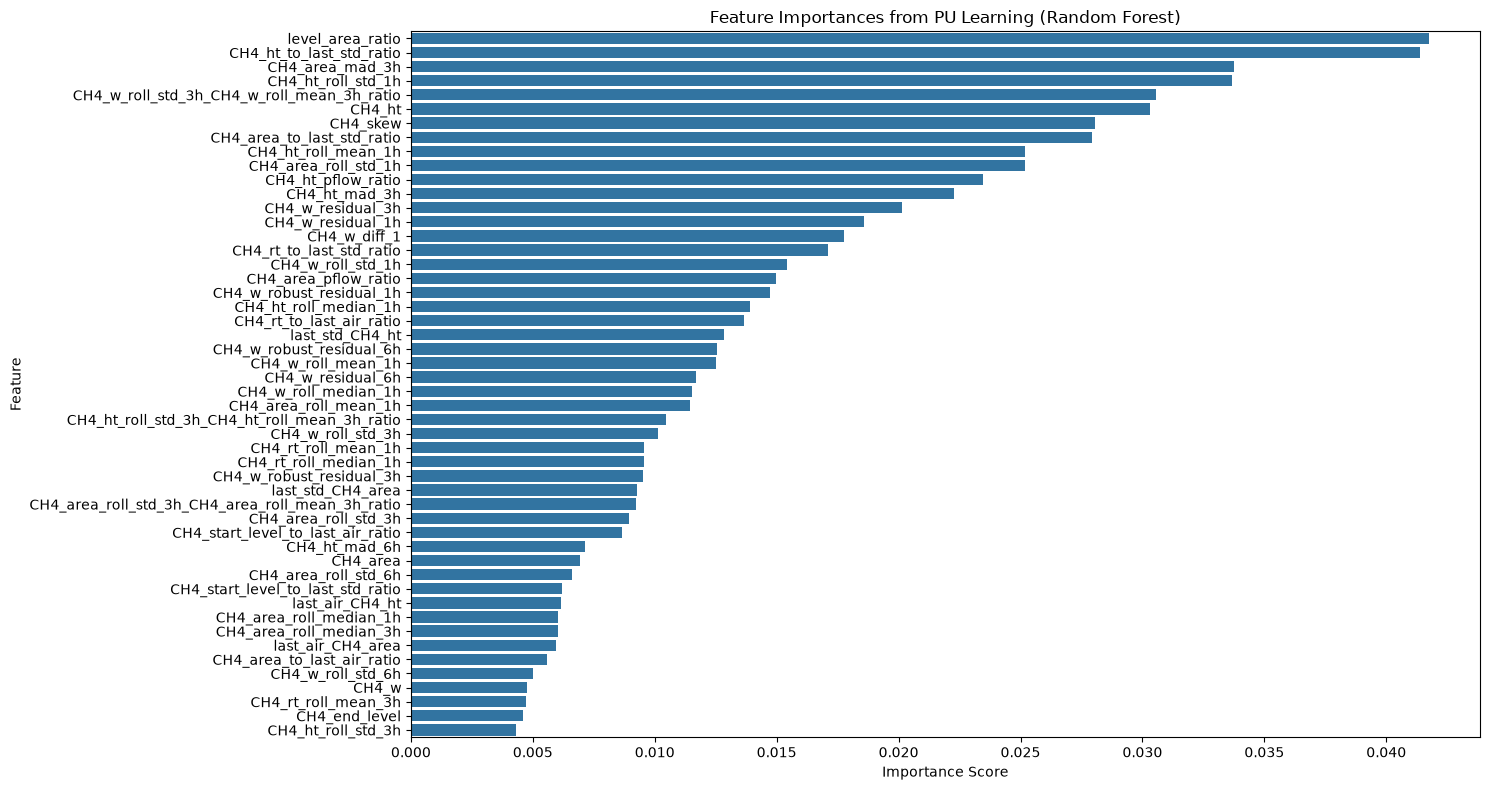

In [11]:
base_rf = pu_estimator.estimator

importances = base_rf.feature_importances_

feature_imp_df = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(15, 8))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(50))
plt.title('Feature Importances from PU Learning (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [12]:
feature_imp_df['Feature'].tolist()

['level_area_ratio',
 'CH4_ht_to_last_std_ratio',
 'CH4_area_mad_3h',
 'CH4_ht_roll_std_1h',
 'CH4_w_roll_std_3h_CH4_w_roll_mean_3h_ratio',
 'CH4_ht',
 'CH4_skew',
 'CH4_area_to_last_std_ratio',
 'CH4_ht_roll_mean_1h',
 'CH4_area_roll_std_1h',
 'CH4_ht_pflow_ratio',
 'CH4_ht_mad_3h',
 'CH4_w_residual_3h',
 'CH4_w_residual_1h',
 'CH4_w_diff_1',
 'CH4_rt_to_last_std_ratio',
 'CH4_w_roll_std_1h',
 'CH4_area_pflow_ratio',
 'CH4_w_robust_residual_1h',
 'CH4_ht_roll_median_1h',
 'CH4_rt_to_last_air_ratio',
 'last_std_CH4_ht',
 'CH4_w_robust_residual_6h',
 'CH4_w_roll_mean_1h',
 'CH4_w_residual_6h',
 'CH4_w_roll_median_1h',
 'CH4_area_roll_mean_1h',
 'CH4_ht_roll_std_3h_CH4_ht_roll_mean_3h_ratio',
 'CH4_w_roll_std_3h',
 'CH4_rt_roll_mean_1h',
 'CH4_rt_roll_median_1h',
 'CH4_w_robust_residual_3h',
 'last_std_CH4_area',
 'CH4_area_roll_std_3h_CH4_area_roll_mean_3h_ratio',
 'CH4_area_roll_std_3h',
 'CH4_start_level_to_last_air_ratio',
 'CH4_ht_mad_6h',
 'CH4_area',
 'CH4_area_roll_std_6h',
 'CH4

In [9]:
best_threshold = 0.85
y_prob = pu_estimator.predict_proba(X_test_final)[:,1]
y_prob = np.clip(y_prob, 0.0, 1.0)
y_proba_best = (y_prob >= best_threshold).astype(int)

analysis_df = pd.DataFrame({
    'original_index': X_test_final.index,
    'true_label': y_test.values,
    'predicted_label': y_proba_best,
    'predicted_prob': y_prob
}, index=X_test_final.index)

errors_df = analysis_df[analysis_df['true_label'] != analysis_df['predicted_label']].copy()

def error_type(row):
    if row['true_label'] == 1 and row['predicted_label'] == 0:
        return 'False Negative, actual 1; predicted 0, confirmed flag, but model missed'
    elif row['true_label'] == 0 and row['predicted_label'] == 1:
        return 'Potential Hidden Flag( actual 0; predicted 1; Unlabled, but high prob)'

errors_df['error_type'] = errors_df.apply(error_type, axis=1)

errors_df['severity'] = (errors_df['predicted_prob'] - best_threshold).abs()

errors_df = errors_df.join(X_test_final)

errors_df = errors_df.sort_values(by='severity', ascending=False)

print('==== ERROR SUMMARY===')
print(f'error per: {len(errors_df)/len(X_test_final):.2%}')

#errors_df.to_csv('error_analysis_with_index.csv', index=True)#=========
fp_flag_df = errors_df[errors_df['error_type'].str.contains('Potential Hidden Flag')].copy()

fp_flag_df.head(20)

/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


==== ERROR SUMMARY===
error per: 7.94%


,original_index,true_label,predicted_label,predicted_prob,error_type,severity,pflow,tmod,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,is_air,is_std,last_std_CH4_ht,last_air_CH4_ht,last_std_CH4_area,last_air_CH4_area,last_std_CH4_rt,last_air_CH4_rt,last_std_CH4_start_level,last_air_CH4_start_level,level_rt_ratio,rt_position,baseline_slope,level_area_ratio,CH4_area_diff_1,CH4_ht_diff_1,CH4_w_diff_1,CH4_area_lag_1,CH4_rt_lag_1,CH4_ht_lag_1,pflow_lag_1,CH4_w_lag_1,CH4_w_roll_std_40min,CH4_w_roll_std_2h,CH4_w_roll_std_6h,CH4_w_roll_std_24h,CH4_w_roll_std_2D,CH4_end_time_roll_std_40min,CH4_end_time_roll_std_2h,CH4_end_time_roll_std_6h,CH4_end_time_roll_std_24h,CH4_end_time_roll_std_2D,CH4_ht_roll_std_40min,CH4_ht_roll_std_2h,CH4_ht_roll_std_6h,CH4_ht_roll_std_24h,CH4_ht_roll_std_2D,CH4_area_roll_std_40min,CH4_area_roll_std_2h,CH4_area_roll_std_6h,CH4_area_roll_std_24h,CH4_area_roll_std_2D,CH4_rt_roll_mean_40min,CH4_rt_residual_40min,CH4_rt_roll_mean_2h,CH4_rt_residual_2h,CH4_rt_roll_mean_6h,CH4_rt_residual_6h,CH4_rt_roll_mean_24h,CH4_rt_residual_24h,CH4_rt_roll_mean_2D,CH4_rt_residual_2D,CH4_w_roll_mean_40min,CH4_w_residual_40min,CH4_w_roll_mean_2h,CH4_w_residual_2h,CH4_w_roll_mean_6h,CH4_w_residual_6h,CH4_w_roll_mean_24h,CH4_w_residual_24h,CH4_w_roll_mean_2D,CH4_w_residual_2D,CH4_ht_roll_mean_40min,CH4_ht_residual_40min,CH4_ht_roll_mean_2h,CH4_ht_residual_2h,CH4_ht_roll_mean_6h,CH4_ht_residual_6h,CH4_ht_roll_mean_24h,CH4_ht_residual_24h,CH4_ht_roll_mean_2D,CH4_ht_residual_2D,CH4_area_roll_mean_40min,CH4_area_residual_40min,CH4_area_roll_mean_2h,CH4_area_residual_2h,CH4_area_roll_mean_6h,CH4_area_residual_6h,CH4_area_roll_mean_24h,CH4_area_residual_24h,CH4_area_roll_mean_2D,CH4_area_residual_2D,CH4_end_time_CH4_start_time_diff_cross,last_std_CH4_ht_last_air_CH4_ht_diff_cross,CH4_ht_last_std_CH4_ht_diff_cross,CH4_ht_last_air_CH4_ht_diff_cross,last_std_CH4_ht_log,last_air_CH4_ht_log,CH4_w_CH4_ht_multi,CH4_end_time_CH4_start_time_diff_cross_last_std_CH4_ht_log_multi,CH4_end_time_CH4_start_time_diff_cross_last_air_CH4_ht_log_multi,CH4_area_CH4_w_CH4_ht_multi_ratio,CH4_ht_CH4_area_ratio,CH4_w_CH4_end_time_CH4_start_time_diff_cross_ratio,CH4_ht_last_air_CH4_ht_ratio,last_std_CH4_ht_last_air_CH4_ht_ratio,CH4_start_level_CH4_end_level_ratio,CH4_area_last_std_CH4_area_ratio,CH4_start_level_last_std_CH4_start_level_ratio,CH4_w_roll_std_40min_CH4_w_roll_mean_40min_ratio,CH4_ht_roll_std_40min_CH4_ht_roll_mean_40min_ratio,CH4_area_roll_std_40min_CH4_area_roll_mean_40min_ratio,CH4_w_roll_std_2h_CH4_w_roll_mean_2h_ratio,CH4_ht_roll_std_2h_CH4_ht_roll_mean_2h_ratio,CH4_area_roll_std_2h_CH4_area_roll_mean_2h_ratio,CH4_w_roll_std_6h_CH4_w_roll_mean_6h_ratio,CH4_ht_roll_std_6h_CH4_ht_roll_mean_6h_ratio,CH4_area_roll_std_6h_CH4_area_roll_mean_6h_ratio,CH4_ht_diff_1_CH4_ht_lag_1_per_change,last_std_CH4_ht_last_air_CH4_ht_per_change,CH4_w_relative_per_2h,CH4_w_relative_per_7h,CH4_end_time_relative_per_2h,CH4_end_time_relative_per_7h,CH4_ht_relative_per_2h,CH4_ht_relative_per_7h,CH4_w_2h_zcore_res_gen,CH4_w_per_rank_7h,CH4_w_per_rank_7D,CH4_w_per_rank_30D,CH4_skew_per_rank_7h,CH4_skew_per_rank_7D,CH4_skew_per_rank_30D,CH4_ht_per_rank_7h,CH4_ht_per_rank_7D,CH4_ht_per_rank_30D
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-07-06 12:05:00,2025-07-06 12:05:00,0,1,1.0,Potential Hidden Flag( actual 0; predicted 1; ...,0.15,800.200012,40.0,96.000000,7.79,165991.0,1439762.0,1.07,82.800003,134.800003,28455.0,28635.0,1,0,163544.0,165960.0,1443623.0,1442543.0,96.000000,96.000000,28371.0,28199.0,0.541667,1.694480,23.106546,0.019889,-3861.0,2447.0,-0.13,1443623.0,96.000000,163544.0,808.799988,7.92,0.084853,0.050761,0.030705,0.021510,0.018146,0.141421,0.163299,0.155509,0.125469,0.111545,1708.369995,1284.904297,946.466309,854.504333,955.984436,763.675354,5864.546875,6656.481934,6186.773926,7806.000977,96.000000,

-----------------------------------